In [ ]:
from pyspark.sql import SparkSession

# =========================================================
# 0. Initialisation PySpark
# =========================================================

# Note: Dans Google Colab, assurez-vous d'avoir installé pyspark
print("[*] Initialisation de la Spark Session...")
try:
    spark = (SparkSession.builder
            .appName("AutoRAG-Ingestion")
            .master("local[*]")
            .config("spark.driver.memory", "4g")
            .config("spark.executor.memory", "4g")
            .config("spark.sql.execution.arrow.pyspark.enabled", "true")
            .getOrCreate())
    print("[+] Spark Session prête.")
except Exception as e:
    print(f"[!] Erreur lors de l'initialisation de Spark : {e}")
    spark = None


# SET UP

In [1]:
# Fix pour les erreurs d'installation précédentes
#!pip install --upgrade pip setuptools
!pip install -q pymupdf4llm pylance lancedb scikit-learn langchain-text-splitters sentence-transformers pandas langchain pyarrow torch elasticsearch requests numpy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.3/77.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 993.6/993.6 kB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 334.8/334.8 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 75.3 MB/s eta 0:00:00


In [2]:
!apt-get update && apt-get install -y zstd

!curl -fsSL https://ollama.com/install.sh | sh
!nohup ollama serve > ollama.log 2>&1 &

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,705 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,451 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy

In [3]:
!sudo apt update
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
#Check this site for the latest download link https://www.apache.org/dyn/closer.lua/spark/spark-3.2.1/spark-3.2.1-bin-hadoop3.2.tgz
!wget -q https://dlcdn.apache.org/spark/spark-3.2.1/spark-3.2.1-bin-hadoop3.2.tgz
!tar xf spark-3.2.1-bin-hadoop3.2.tgz
!pip install -q findspark
!pip install pyspark
!pip install py4j


Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
66 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as re

In [4]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import re, time, hashlib, json, logging, random, itertools
import requests
import numpy as np
import pandas as pd
import lancedb
import torch
import concurrent.futures
import pymupdf4llm
from typing import Optional, List, Dict, Generator, Any, Tuple
from openai import OpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer, CrossEncoder


# CONFIG OPENROUTER

In [5]:
# === CELLULE DE DÉFINITION ===
import os
from openai import OpenAI
from typing import Optional

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY", "")

class OpenRouterClient:
    def __init__(self, api_key: str = OPENROUTER_API_KEY, model: str = "meta-llama/llama-3.3-70b-instruct"):
        self.api_key = api_key
        if not self.api_key:
            print("[!] Attention: Clé API OpenRouter non configurée.")
        self.client = OpenAI(
            base_url="https://openrouter.ai/api/v1",
            api_key=self.api_key,
            default_headers={"HTTP-Referer": "https://colab.research.google.com/", "X-Title": "TEKNO AutoRAG Belgium"}
        )
        self.default_model = model

    def chat(self, prompt: str, model: Optional[str] = None, system_prompt: str = "You are a helpful assistant.") -> str:
        selected_model = model or self.default_model
        try:
            response = self.client.chat.completions.create(
                model=selected_model,
                messages=[{"role": "system", "content": system_prompt}, {"role": "user", "content": prompt}],
                max_tokens=4096,
                temperature=0.2
            )
            return response.choices[0].message.content
        except Exception as e:
            return f"Error: {e}"

def setup_openrouter(api_key: Optional[str] = None, model: str = "meta-llama/llama-3.3-70b-instruct") -> OpenRouterClient:
    """
    Initialise et retourne le client OpenRouterClient.
    """
    key = api_key or OPENROUTER_API_KEY
    return OpenRouterClient(api_key=key, model=model)

or_client = setup_openrouter()


# Configuration & Chargement des Modèles

In [12]:
# === CELLULE DE DÉFINITION ===
import os

def run_config(use_drive: bool = True) -> dict:
    """
    Initialise la configuration de l'environnement AutoRAG.
    Gère le montage conditionnel de Google Drive, l'initialisation de Spark,
    la création des répertoires et l'identification des fichiers PDF.

    Retourne :
        dict : Dictionnaire contenant les paramètres de configuration.
    """
    # Configuration des variables d'environnement pour l'initialisation de Spark et des transformers
    os.environ["TOKENIZERS_PARALLELISM"] = "false"
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["MKL_NUM_THREADS"] = "1"

    import json

    # 0. Initialisation PySpark (Lazy import)
    print("[*] Initialisation de la Spark Session...")
    try:
        from pyspark.sql import SparkSession
        spark = (SparkSession.builder
                .appName("AutoRAG-Ingestion")
                .master("local[*]")
                .config("spark.driver.memory", "4g")
                .config("spark.executor.memory", "4g")
                .config("spark.sql.execution.arrow.pyspark.enabled", "true")
                .getOrCreate())
        print("[+] Spark Session prête.")
    except Exception as e:
        print(f"[!] Erreur lors de l'initialisation de Spark : {e}")
        spark = None

    # 1. Détermination du chemin de base (BASE_PATH)
    if os.path.exists("/content"):
        # Environnement Google Colab
        if use_drive:
            try:
                from google.colab import drive
                print("[*] Tentative de montage Google Drive...")
                drive.mount("/content/drive", force_remount=True)
                BASE_PATH = "/content/drive/MyDrive/AutoRAG"
                print("[+] Google Drive monté.")
            except Exception as e:
                print(f"[!] Drive non monté : {e}")
                print("[!] Fallback local activé.")
                BASE_PATH = "/content/AutoRAG"
        else:
            BASE_PATH = "/content/AutoRAG"
    else:
        # Environnement local (Windows/Linux/Mac)
        BASE_PATH = os.path.join(os.getcwd(), "AutoRAG")
        print(f"[i] Environnement local détecté. BASE_PATH défini sur : {BASE_PATH}")

    # 2. Définition des dossiers du projet
    DATASET_DIR = os.path.join(BASE_PATH, "dataset")
    KNOWLEDGE_DIR = os.path.join(DATASET_DIR, "knowledge_base")
    AUDIT_DIR = os.path.join(DATASET_DIR, "audit_inputs")
    GROUND_TRUTH_PATH = os.path.join(DATASET_DIR, "ground_truth_incoherences.json")
    # FIX: Use local disk for LanceDB to avoid GDrive FUSE limitations
    DB_PATH = "/content/lancedb_storage_local" if os.path.exists("/content") else os.path.join(BASE_PATH, "storage", "lancedb_hrag_belgium")
    SHAPRAG_DIR = "/content/SHapRAG" if os.path.exists("/content") else os.path.join(os.getcwd(), "SHapRAG")

    # Création des répertoires requis
    for path in [BASE_PATH, DATASET_DIR, KNOWLEDGE_DIR, AUDIT_DIR, os.path.join(BASE_PATH, "storage"), SHAPRAG_DIR]:
        os.makedirs(path, exist_ok=True)

    print("[+] BASE_PATH      :", BASE_PATH)
    print("[+] KNOWLEDGE_DIR  :", KNOWLEDGE_DIR)
    print("[+] AUDIT_DIR      :", AUDIT_DIR)
    print("[+] DB_PATH        :", DB_PATH)

    # 3. Liste des fichiers PDF
    def list_pdf_files(folder):
        if not os.path.exists(folder):
            return []
        return [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith(".pdf")
        ]

    KNOWLEDGE_PDFS = list_pdf_files(KNOWLEDGE_DIR)
    AUDIT_PDFS = list_pdf_files(AUDIT_DIR)
    PDF_PATHS = KNOWLEDGE_PDFS + AUDIT_PDFS

    print(f"[+] PDF base de connaissance : {len(KNOWLEDGE_PDFS)}")
    print(f"[+] PDF à auditer            : {len(AUDIT_PDFS)}")
    print(f"[+] Total PDF                : {len(PDF_PATHS)}")

    if not KNOWLEDGE_PDFS:
        print("[!] Aucun document trouvé dans knowledge_base/. Ajoutez les PDF propres permanents.")

    if not AUDIT_PDFS:
        print("[!] Aucun document trouvé dans audit_inputs/. Ajoutez les PDF à auditer.")

    # 4. Chargement optionnel de la Ground Truth
    def load_ground_truth_optional(path):
        if not os.path.exists(path):
            print("[i] Aucun ground truth chargé. Ce n'est pas bloquant.")
            return []
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)

    ground_truth = load_ground_truth_optional(GROUND_TRUTH_PATH)
    print(f"[i] Ground truth disponible pour évaluation : {len(ground_truth)} entrées")

    # 5. Modèles par défaut
    EMBEDDING_MODEL = "mixedbread-ai/mxbai-embed-large-v1"
    RERANKER_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"

    config = {
        "BASE_PATH": BASE_PATH,
        "DATASET_DIR": DATASET_DIR,
        "KNOWLEDGE_DIR": KNOWLEDGE_DIR,
        "AUDIT_DIR": AUDIT_DIR,
        "GROUND_TRUTH_PATH": GROUND_TRUTH_PATH,
        "DB_PATH": DB_PATH,
        "SHAPRAG_DIR": SHAPRAG_DIR,
        "KNOWLEDGE_PDFS": KNOWLEDGE_PDFS,
        "AUDIT_PDFS": AUDIT_PDFS,
        "PDF_PATHS": PDF_PATHS,
        "ground_truth": ground_truth,
        "EMBEDDING_MODEL": EMBEDDING_MODEL,
        "RERANKER_MODEL": RERANKER_MODEL,
        "spark": spark,
        # Initialisation paresseuse des objets
        "device": None,
        "embedder": None,
        "reranker": None,
        "db": None,
    }
    return config

config = run_config()


[*] Initialisation de la Spark Session...
[+] Spark Session prête.
[*] Tentative de montage Google Drive...
Mounted at /content/drive
[+] Google Drive monté.
[+] BASE_PATH      : /content/drive/MyDrive/AutoRAG
[+] KNOWLEDGE_DIR  : /content/drive/MyDrive/AutoRAG/dataset/knowledge_base
[+] AUDIT_DIR      : /content/drive/MyDrive/AutoRAG/dataset/audit_inputs
[+] DB_PATH        : /content/lancedb_storage_local
[+] PDF base de connaissance : 2
[+] PDF à auditer            : 1
[+] Total PDF                : 3
[i] Ground truth disponible pour évaluation : 50 entrées


# Ingestion — Base de connaissance + Documents à auditer


In [13]:
# === CELLULE DE DÉFINITION ===
import os
import concurrent.futures
import hashlib
import json
import re
import pymupdf4llm

from langchain_text_splitters import RecursiveCharacterTextSplitter, MarkdownHeaderTextSplitter

# --- Début des filtres de criticité ---
CRITICAL_UNITS = r"(?:mSv|Sv|Bq|GBq|TBq|°C|K|MPa|kPa|Pa|ppm|ppb|m³|m3|m²|m2|m/s|mL/g|kg/m³|g/cm³|an|ans|mois|jours?|h|heures?|min|sec|%|MW|keV|MeV|bars?|m|km|kg|g|mg|t|tonnes?|fûts?|colis)"

CRITICAL_NUMERIC_PATTERN = re.compile(r"(?<![a-zA-Z])[+-]?\d+(?:[.,]\d+)?(?:e[+-]?\d+|[x×*]\s*10\s*\^?\s*[+-]?\d+)?\s*" + CRITICAL_UNITS + r"(?:\s*/\s*" + CRITICAL_UNITS + r")?(?![a-zA-Z])", re.I)

CRITICAL_PATTERNS = [
    # 1. Valeurs avec unités
    CRITICAL_NUMERIC_PATTERN,

    # 2. Inclusions logiques (min_patterns depuis filtre_qualite_portable)
    re.compile(r'(\d+(?:\.\d+)?)\s*(?:ans?|annees?)?\s*(?:ou plus|et plus|et au-dela|et plus)', re.I),
    re.compile(r'au\s*moins\s*(\d+(?:\.\d+)?)', re.I),
    re.compile(r'minimum\s*(\d+(?:\.\d+)?)', re.I),
    re.compile(r'≥\s*(\d+(?:\.\d+)?)', re.I),
    re.compile(r'>\s*(\d+(?:\.\d+)?)', re.I),
    re.compile(r'a?\s*partir\s*de\s*(\d+(?:\.\d+)?)', re.I),

    # 3. Inclusions logiques (range_patterns)
    re.compile(r'(\d+(?:\.\d+)?)\s*(?:a|à|-)\s*(\d+(?:\.\d+)?)', re.I),
    re.compile(r'entre\s*(\d+(?:\.\d+)?)\s*et\s*(\d+(?:\.\d+)?)', re.I),

    # 4. Sémantique / Temporel / Causal
    re.compile(r"\b(?:doit|doivent|obligatoire|exigé|requis|interdit|proscrit|risque|danger|anomalie|incident|accident|procédure|action|mesure|défaillance|cause|conséquence|impact|vérifier|contrôler|assurer)\b", re.I),
    re.compile(r"\b(?:avant|après|délai|immédiatement|lors de|pendant|annuel(?:le)?|mensuel(?:le)?|hebdomadaire|quotidien(?:ne)?|fréquence|périodicité)\b", re.I)
]

def is_text_critical(text: str) -> tuple:
    """Retourne (has_numeric, is_critical)"""
    if not text:
        return False, False

    has_numeric = bool(CRITICAL_NUMERIC_PATTERN.search(text))
    is_critical = False

    for pat in CRITICAL_PATTERNS:
        if pat.search(text):
            is_critical = True
            break

    return has_numeric, is_critical
# --- Fin des filtres ---

def parse_single_pdf(pdf_path, dataset_split="audit_input"):
    """
    Parse un PDF local depuis Google Drive ou local.

    dataset_split :
    - knowledge_base : document propre permanent
    - audit_input    : document à auditer
    """
    if not os.path.exists(pdf_path):
        print(f"[!] Fichier introuvable : {pdf_path}")
        return []

    name = os.path.basename(pdf_path)
    print(f"[*] Parsing {name} ({dataset_split})...")

    try:
        pages = pymupdf4llm.to_markdown(
            pdf_path,
            page_chunks=True,
            show_progress=False
        )

        headers_to_split_on = [
            ("#", "Header 1"),
            ("##", "Header 2"),
            ("###", "Header 3"),
        ]
        markdown_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)

        child_splitter = RecursiveCharacterTextSplitter(
            chunk_size=1600,
            chunk_overlap=400,
            separators=["\n\n", "\n", ". ", "; ", " ", ""]
        )

        doc_hash = hashlib.md5(pdf_path.encode("utf-8")).hexdigest()[:8]

        # numeric_regex and units have been moved to global CRITICAL_NUMERIC_PATTERN

        local_nodes = []
        seen_hashes = set()

        for i, p in enumerate(pages):
            p_num = p.get("metadata", {}).get("page", i) + 1
            content = (p.get("text", "") or "").strip()

            if not content:
                continue

            md_chunks = markdown_splitter.split_text(content)

            sub_texts_with_meta = []
            for md_chunk in md_chunks:
                splits = child_splitter.split_text(md_chunk.page_content)
                for split in splits:
                    sub_texts_with_meta.append((split, md_chunk.metadata))

            for j, (sub_text, md_meta) in enumerate(sub_texts_with_meta):
                if not sub_text.strip():
                    continue

                has_numeric, is_critical = is_text_critical(sub_text)

                # Dédoublonnage MD5
                chunk_hash = hashlib.md5(sub_text.strip().encode("utf-8")).hexdigest()
                if chunk_hash in seen_hashes:
                    continue
                seen_hashes.add(chunk_hash)

                node_id = f"{doc_hash}::P{p_num}::C{j}"

                # Détection de section
                breadcrumb = f"Page {p_num}"
                md_headers = [md_meta[k] for k in ["Header 1", "Header 2", "Header 3"] if k in md_meta]

                if md_headers:
                    breadcrumb = f"Page {p_num} > {' > '.join(md_headers)}"
                else:
                    # Capture de 1 à 6 '#', ignore les '#' de fermeture éventuels typiques du format ATX
                    section_match = re.search(r"^(#{1,6})\s+(.*?)(?:\s+#+)?$", sub_text, re.MULTILINE)
                    if section_match:
                        raw_title = section_match.group(2).strip()
                        # Nettoie le formatage Markdown résiduel dans le titre (ex: **Titre** -> Titre)
                        clean_title = re.sub(r'[*_]{1,3}', '', raw_title).strip()
                        breadcrumb = f"Page {p_num} > {clean_title}"

                local_nodes.append({
                    "node_id": node_id,
                    "human_ref": f"📄 {name} → {breadcrumb} / Chunk {j}",
                    "source": name,
                    "source_path": pdf_path,
                    "start_page": p_num,
                    "end_page": p_num,
                    "breadcrumb": breadcrumb,
                    "content": sub_text,
                    "prev_content": "",
                    "next_content": "",
                    "sub_chunks_json": json.dumps([sub_text], ensure_ascii=False),
                    "num_sub_chunks": 1,
                    "has_numeric": has_numeric,
                    "is_critical": is_critical,
                    "cluster_id": -1,
                    "dataset_split": dataset_split,
                    "is_knowledge_base": dataset_split == "knowledge_base",
                    "is_audit_input": dataset_split == "audit_input"
                })

        # Ajout des Breadcrumbs Contextuels
        for idx in range(len(local_nodes)):
            if idx > 0:
                local_nodes[idx]["prev_content"] = local_nodes[idx-1]["content"][:600]
            if idx < len(local_nodes) - 1:
                local_nodes[idx]["next_content"] = local_nodes[idx+1]["content"][:600]

        return local_nodes

    except Exception as e:
        print(f"[!] Erreur parsing {name}: {e}")
        return []

def get_lancedb_table_names(db):
    """
    Récupère proprement les noms de table LanceDB de manière compatible avec différentes versions.
    """
    table_names = db.list_tables()
    if hasattr(table_names, "tables"):
        table_names = table_names.tables
    return table_names

def run_ingestion(config: dict) -> tuple:
    """
    Exécute le pipeline d'ingestion AutoRAG en utilisant la configuration fournie.
    Initialise les modèles d'embedding et de reranking de façon tardive (Lazy loading).
    Enregistre les données ingérées dans LanceDB.

    Retourne :
        (lancedb.Table, dict) : La table node_table et la configuration mise à jour.
    """
    # Configuration des variables d'environnement pour l'initialisation des transformers
    os.environ["TOKENIZERS_PARALLELISM"] = "false"
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["MKL_NUM_THREADS"] = "1"

    KNOWLEDGE_PDFS = config["KNOWLEDGE_PDFS"]
    AUDIT_PDFS = config["AUDIT_PDFS"]
    spark = config.get("spark")
    DB_PATH = config["DB_PATH"]
    EMBEDDING_MODEL = config["EMBEDDING_MODEL"]
    RERANKER_MODEL = config["RERANKER_MODEL"]

    print("[*] Ingestion des documents Auto-RAG...")

    node_records = []
    pdf_jobs = []

    for path in KNOWLEDGE_PDFS:
        pdf_jobs.append((path, "knowledge_base"))

    for path in AUDIT_PDFS:
        pdf_jobs.append((path, "audit_input"))

    if spark is not None:
        print(f"[*] Utilisation de PySpark pour distribuer le parsing ({len(pdf_jobs)} documents)...")
        dist_jobs = spark.sparkContext.parallelize(pdf_jobs, numSlices=len(pdf_jobs))
        node_records_rdd = dist_jobs.flatMap(lambda job: parse_single_pdf(job[0], job[1]))
        node_records = node_records_rdd.collect()

        try:
            spark.stop()
            print("[+] Spark Session arrêtée avec succès.")
            if "spark" in config:
                config["spark"] = None
        except Exception as e:
            print(f"[!] Erreur arrêt Spark Session : {e}")
    else:
        print("[!] Spark non disponible, fallback sur ProcessPoolExecutor...")
        with concurrent.futures.ProcessPoolExecutor(max_workers=4) as executor:
            futures = [
                executor.submit(parse_single_pdf, path, split)
                for path, split in pdf_jobs
            ]
            for future in concurrent.futures.as_completed(futures):
                node_records.extend(future.result())

    if not node_records:
        print("[!] Aucun nœud extrait.")
        return None, config

    print(f"\n[*] Initialisation propre des modèles et de LanceDB (Post-Spark)...")

    import gc
    import time
    import torch
    import lancedb
    from sentence_transformers import SentenceTransformer, CrossEncoder

    torch.set_num_threads(1)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"[+] Device détecté : {device} (Thread pool PyTorch configuré à 1 thread)")

    t_mod = time.time()
    print(f"[*] Initialisation de l'embedder ({EMBEDDING_MODEL})...")
    embedder = SentenceTransformer(EMBEDDING_MODEL, device=device)

    print(f"[*] Initialisation du reranker ({RERANKER_MODEL})...")
    reranker = CrossEncoder(RERANKER_MODEL, max_length=512, device=device)
    print(f"[+] Modèles initialisés en {round(time.time() - t_mod, 2)}s.")

    print(f"[*] Connexion à LanceDB sur {DB_PATH}...")
    os.makedirs(DB_PATH, exist_ok=True)
    db = lancedb.connect(DB_PATH)
    print("[+] Connexion LanceDB établie.")

    print(f"[*] Calcul des embeddings pour {len(node_records)} nœuds...")
    node_texts = [r.get("content", "") for r in node_records]

    node_vectors = embedder.encode(
        node_texts,
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=True
    )

    for i, rec in enumerate(node_records):
        rec["vector"] = node_vectors[i].tolist()

    table_names = get_lancedb_table_names(db)

    if "node_table" in table_names:
        db.drop_table("node_table")

    tbl = db.create_table(
        "node_table",
        data=node_records,
        mode="overwrite"
    )

    tbl.create_fts_index("content")

    print(f"[+] Ingestion terminée : {len(node_records)} nœuds indexés.")
    print(f"[+] Base de connaissance : {len([r for r in node_records if r['dataset_split'] == 'knowledge_base'])} nœuds")
    print(f"[+] Documents à auditer : {len([r for r in node_records if r['dataset_split'] == 'audit_input'])} nœuds")

    config["device"] = device
    config["embedder"] = embedder
    config["reranker"] = reranker
    config["db"] = db

    return tbl, config

tbl, config = run_ingestion(config)

[*] Ingestion des documents Auto-RAG...
[*] Utilisation de PySpark pour distribuer le parsing (3 documents)...
[+] Spark Session arrêtée avec succès.

[*] Initialisation propre des modèles et de LanceDB (Post-Spark)...
[+] Device détecté : cuda (Thread pool PyTorch configuré à 1 thread)
[*] Initialisation de l'embedder (mixedbread-ai/mxbai-embed-large-v1)...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[*] Initialisation du reranker (cross-encoder/ms-marco-MiniLM-L-6-v2)...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[+] Modèles initialisés en 6.6s.
[*] Connexion à LanceDB sur /content/lancedb_storage_local...
[+] Connexion LanceDB établie.
[*] Calcul des embeddings pour 332 nœuds...


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

[+] Ingestion terminée : 332 nœuds indexés.
[+] Base de connaissance : 298 nœuds
[+] Documents à auditer : 34 nœuds


# Get lancedb tables

In [ ]:
# === PATCH : compatibilité db.list_tables() LanceDB ===

def get_lancedb_table_names(db):
    """
    Compatible avec plusieurs versions de LanceDB :
    - certaines retournent une liste directe
    - d'autres retournent un objet avec .tables
    """
    tables = db.list_tables()

    if hasattr(tables, "tables"):
        return tables.tables

    if isinstance(tables, list):
        return tables

    try:
        return list(tables)
    except Exception:
        return []

In [ ]:
# === CELLULE DEBUG — Vérification LanceDB / fichiers / node_table ===

import os

print("BASE_PATH :", BASE_PATH)
print("DATASET_DIR :", DATASET_DIR)
print("KNOWLEDGE_DIR :", KNOWLEDGE_DIR)
print("AUDIT_DIR :", AUDIT_DIR)
print("DB_PATH :", DB_PATH)

print("\nTables LanceDB disponibles :")
print(db.list_tables())

print("\nPDF knowledge_base :")
print(KNOWLEDGE_PDFS)

print("\nPDF audit_inputs :")
print(AUDIT_PDFS)

if "node_table" in get_lancedb_table_names(db):
    tbl = db.open_table("node_table")
    df_debug = tbl.to_pandas()
    print("\n✅ node_table existe")
    print("Nombre de lignes :", len(df_debug))
    print(df_debug[["source", "dataset_split"]].head())
else:
    print("\n❌ node_table absente : il faut relancer la cellule d'ingestion.")

NameError: name 'BASE_PATH' is not defined

# Clustering preparation

In [14]:
# === CELLULE DE DÉFINITION ===
import time
import json
import numpy as np
import pandas as pd

from sklearn.cluster import MiniBatchKMeans, BisectingKMeans
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

def get_lancedb_table_names(db):
    """
    Récupère proprement les noms de table LanceDB de manière compatible avec différentes versions.
    """
    table_names = db.list_tables()
    if hasattr(table_names, "tables"):
        table_names = table_names.tables
    return table_names

def upgrade_cluster_routing(db, table_name, or_client, metrics, embedder=None):
    """
    Version ajustée sans changer l'esprit HRAG v3.2 :
    - on garde l'alpha blending ;
    - on garde le clustering hiérarchique ;
    - on garde les routing tables ;
    - mais on sépare knowledge_base et audit_input.

    Objectif :
    éviter que les documents de base de connaissance et les documents à auditer
    soient mélangés dans les mêmes clusters.
    """
    t_km = time.time()

    if table_name not in get_lancedb_table_names(db):
        raise ValueError(f"La table {table_name} n'existe pas. Lance d'abord l'ingestion.")

    tbl = db.open_table(table_name)
    df = tbl.to_pandas()

    if df.empty:
        raise ValueError(f"La table {table_name} est vide.")

    if "dataset_split" not in df.columns:
        raise ValueError(
            "La colonne dataset_split est absente. "
            "Impossible de séparer knowledge_base et audit_input."
        )

    df["dataset_split"] = df["dataset_split"].astype(str)

    df_kb = df[df["dataset_split"] == "knowledge_base"].copy()
    df_audit = df[df["dataset_split"] == "audit_input"].copy()

    if df_kb.empty:
        raise ValueError("Aucun document knowledge_base trouvé dans node_table.")

    if df_audit.empty:
        raise ValueError("Aucun document audit_input trouvé dans node_table.")

    print(f"[+] Nœuds knowledge_base : {len(df_kb)}")
    print(f"[+] Nœuds audit_input    : {len(df_audit)}")

    # =====================================================
    # Fonction interne : clustering d'un seul groupe
    # =====================================================
    def cluster_one_group(local_df, scope_name, cluster_prefix):
        """
        Clustering HRAG appliqué à un seul sous-ensemble :
        - soit knowledge_base
        - soit audit_input
        """
        local_df = local_df.copy()

        # --- STEP 1 : Alpha blending ---
        print(f"[*] Alpha Blending pour {scope_name}...")

        content_vectors = np.stack(local_df["vector"].values)
        content_vectors = normalize(content_vectors)

        if embedder is not None and "breadcrumb" in local_df.columns:
            try:
                breadcrumb_texts = local_df["breadcrumb"].fillna("Intro").astype(str).tolist()

                meta_vectors = embedder.encode(
                    breadcrumb_texts,
                    normalize_embeddings=True,
                    convert_to_numpy=True,
                    show_progress_bar=False
                )

                # Réduction alpha à 0.10 tant que les breadcrumbs sont de faible qualité
                alpha = 0.10
                combined_vectors = normalize((1 - alpha) * content_vectors + alpha * meta_vectors)

            except Exception as e:
                print(f"[!] Alpha blending désactivé pour {scope_name} : {e}")
                combined_vectors = content_vectors
        else:
            combined_vectors = content_vectors

        # --- STEP 2 : macro clustering ---
        n_nodes = len(local_df)

        local_df["cluster_scope"] = scope_name
        local_df["macro_cluster_id"] = -1
        local_df["macro_label"] = ""
        local_df["local_cluster_id"] = -1
        local_df["cluster_uid"] = ""

        routing_data = []

        if n_nodes < 3:
            centroid = np.mean(combined_vectors, axis=0)
            cluster_uid = f"{cluster_prefix}_0"

            local_df["macro_cluster_id"] = 0
            local_df["macro_label"] = scope_name.upper()
            local_df["local_cluster_id"] = 0
            local_df["cluster_uid"] = cluster_uid

            routing_data.append({
                "vector": centroid.tolist(),
                "cluster_uid": cluster_uid,
                "cluster_scope": scope_name,
                "local_cluster_id": 0,
                "macro_cluster_id": 0,
                "macro_label": scope_name.upper(),
                "label": scope_name,
                "node_count": int(n_nodes),
                "radius": 0.0
            })

            return local_df, routing_data, combined_vectors

        # Formule corrigée pour plus de granularité sur petits corpus
        num_macros = max(4, int(np.sqrt(n_nodes) / 2))
        num_macros = min(num_macros, n_nodes)

        print(f"[*] {scope_name} : création de {num_macros} macro-clusters...")

        macro_km = BisectingKMeans(
            n_clusters=num_macros,
            random_state=42,
            n_init=3
        )

        local_df["macro_cluster_id"] = macro_km.fit_predict(combined_vectors)

        global_cluster_counter = 0

        # Etape 1 : Effectuer tous les calculs de clusters locaux sans appel LLM
        macro_groups = {}
        for m_id in sorted(local_df["macro_cluster_id"].unique()):
            mask = local_df["macro_cluster_id"] == m_id
            macro_df = local_df[mask]
            macro_vectors = combined_vectors[mask.values]

            if len(macro_vectors) < 4:
                n_sub = 1
            else:
                n_sub = max(2, int(len(macro_vectors) / 10))
                n_sub = min(n_sub, len(macro_vectors))

            if n_sub == 1:
                sub_labels = np.zeros(len(macro_vectors), dtype=int)
            else:
                sub_km = MiniBatchKMeans(
                    n_clusters=n_sub,
                    random_state=42,
                    n_init=3,
                    batch_size=256
                )
                sub_labels = sub_km.fit_predict(macro_vectors)

            macro_groups[m_id] = {
                "mask": mask,
                "macro_df": macro_df,
                "macro_vectors": macro_vectors,
                "sub_labels": sub_labels,
                "sub_clusters": {}
            }

            for s_id in sorted(set(sub_labels)):
                sub_mask = sub_labels == s_id
                macro_indices = macro_df.index[sub_mask]

                local_df.loc[macro_indices, "local_cluster_id"] = int(global_cluster_counter)
                local_df.loc[macro_indices, "cluster_uid"] = f"{cluster_prefix}_{global_cluster_counter}"

                macro_groups[m_id]["sub_clusters"][s_id] = {
                    "global_id": global_cluster_counter,
                    "indices": macro_indices,
                    "sub_mask": sub_mask
                }
                global_cluster_counter += 1

        # Etape 2 : Préparer tous les prompts de nommage pour le LLM
        macro_prompts = {}
        sub_prompts = {}

        for m_id, m_info in macro_groups.items():
            sample_nodes = m_info["macro_df"].sample(min(len(m_info["macro_df"]), 3), random_state=42)
            samples_text = "\n".join([
                f"- {str(r.get('breadcrumb', ''))} | {str(r.get('source', ''))}"
                for _, r in sample_nodes.iterrows()
            ])

            macro_prompts[m_id] = f"""
Tu es un expert en audit documentaire de sûreté nucléaire.

Donne un titre MACRO binaire, hautement discriminant et structuré comme suit :
[FOCUS TECHNIQUE MAJEUR] - [PÉRIMÈTRE OU SPÉCIFICITÉ DE L'ÉVALUATION]

Exemples de bon format :
- GESTION DES EFFLUENTS - CRITICITÉ ET CONFINEMENT
- EXPÉRIENCE D'EXPLOITATION - INSTALLATIONS DE TYPE FBFC
- AGRESSIONS EXTERNES - RISQUES SISMIQUES ET MÉTÉOROLOGIQUES

INTERDICTION ABSOLUE d'utiliser les expressions génériques suivantes :
- TESTS DE RÉSISTANCE
- SÛRETÉ NUCLÉAIRE
- SÉCURITÉ NUCLÉAIRE
- RAPPORT D'AVANCEMENT
- ÉTABLISSEMENTS DE CLASSE I
- RAPPORTS

CONTRAINTES :
- Maximum 8 mots au total.
- Pas de verbes, pas de phrases, pas de raisonnement.
- Respecter strictement le séparateur " - " (avec les espaces autour).
- Uniquement en MAJUSCULES.

Extraits représentatifs :
{samples_text}

Réponse :
"""

            for s_id, s_info in m_info["sub_clusters"].items():
                macro_indices = s_info["indices"]
                sample_cluster = local_df.loc[macro_indices].head(3)
                context = "\n---\n".join([
                    f"Source: {str(r.get('source', ''))} | Ref: {str(r.get('breadcrumb', ''))}\n"
                    f"{str(r.get('content', ''))[:350]}"
                    for _, r in sample_cluster.iterrows()
                ])

                sub_prompts[s_info["global_id"]] = f"""
Tu es un expert en audit documentaire nucléaire.
Donne deux thèmes technique unique et précis pour ces extraits.

CONTRAINTE :
- maximum 8 mots par thème
- pas de phrase
- pas de raisonnement
- pas de copie de l'instruction (uniquement les thèmes)
- le premier thème capte la synergie du contenu et doit être explicite
- le deuxième thème doit être complémentaire du premier pour capter plus de nuance
- les thèmes sont séparés par un tiret -

Extraits :
{context}

Réponse :
"""

        # Etape 3 : Appels LLM asynchrones (ThreadPoolExecutor)
        from concurrent.futures import ThreadPoolExecutor
        macro_labels = {}
        sub_labels_dict = {}

        def run_macro_prompt(m_id, prompt):
            try:
                res = or_client.chat(prompt).strip().replace('"', '').upper()
                return m_id, " ".join(res.split()).upper()
            except Exception:
                return m_id, f"{scope_name.upper()}_{m_id}"

        def run_sub_prompt(global_id, prompt):
            try:
                res = or_client.chat(prompt).strip().replace('"', '')
                if len(res.split()) > 10:
                    res = " ".join(res.split()[:5]) + "..."
                return global_id, res
            except Exception:
                return global_id, f"{scope_name}_{global_id}"

        print(f"[*] {scope_name} : Lancement de {len(macro_prompts)} macro-nommages et {len(sub_prompts)} sous-nommages en parallèle...")
        with ThreadPoolExecutor(max_workers=10) as executor:
            macro_futures = [executor.submit(run_macro_prompt, m_id, p) for m_id, p in macro_prompts.items()]
            sub_futures = [executor.submit(run_sub_prompt, gid, p) for gid, p in sub_prompts.items()]

            for f in macro_futures:
                m_id, label = f.result()
                macro_labels[m_id] = label

            for f in sub_futures:
                gid, label = f.result()
                sub_labels_dict[gid] = label

        # Etape 4 : Injection des métadonnées nommées et construction de la routing_table
        for m_id, m_info in macro_groups.items():
            macro_label = macro_labels[m_id]
            local_df.loc[m_info["mask"], "macro_label"] = macro_label

            for s_id, s_info in m_info["sub_clusters"].items():
                global_id = s_info["global_id"]
                cluster_uid = f"{cluster_prefix}_{global_id}"
                sub_mask = s_info["sub_mask"]
                cluster_vectors = m_info["macro_vectors"][sub_mask]
                centroid = np.mean(cluster_vectors, axis=0)

                label = sub_labels_dict[global_id]
                radius = float(
                    np.mean(np.linalg.norm(cluster_vectors - centroid, axis=1))
                ) if len(cluster_vectors) else 0.0

                routing_data.append({
                    "vector": centroid.tolist(),
                    "cluster_uid": cluster_uid,
                    "cluster_scope": scope_name,
                    "local_cluster_id": int(global_id),
                    "macro_cluster_id": int(m_id),
                    "macro_label": macro_label,
                    "label": label,
                    "node_count": int(len(s_info["indices"])),
                    "radius": radius
                })

        return local_df, routing_data, combined_vectors

    # =====================================================
    # Clustering séparé KB / Audit
    # =====================================================
    df_kb_clustered, kb_routing, kb_vectors = cluster_one_group(
        df_kb,
        scope_name="knowledge_base",
        cluster_prefix="kb"
    )

    df_audit_clustered, audit_routing, audit_vectors = cluster_one_group(
        df_audit,
        scope_name="audit_input",
        cluster_prefix="audit"
    )

    df_clustered = pd.concat([df_kb_clustered, df_audit_clustered], ignore_index=True)
    df_clustered["cluster_id"] = df_clustered["local_cluster_id"]

    # =====================================================
    # Mise à jour node_table
    # =====================================================
    if table_name in get_lancedb_table_names(db):
        db.drop_table(table_name)

    tbl = db.create_table(
        table_name,
        data=df_clustered,
        mode="overwrite"
    )

    tbl.create_fts_index("content")

    # =====================================================
    # Routing tables
    # =====================================================
    for tname in ["routing_table", "routing_table_kb", "routing_table_audit"]:
        if tname in get_lancedb_table_names(db):
            db.drop_table(tname)

    routing_all = kb_routing + audit_routing

    rtbl = db.create_table("routing_table", data=routing_all, mode="overwrite")
    db.create_table("routing_table_kb", data=kb_routing, mode="overwrite")
    db.create_table("routing_table_audit", data=audit_routing, mode="overwrite")

    # =====================================================
    # Liens entre clusters audit et clusters KB
    # =====================================================
    audit_kb_links = []

    if audit_routing and kb_routing:
        audit_centroids = np.array([r["vector"] for r in audit_routing])
        kb_centroids = np.array([r["vector"] for r in kb_routing])

        sim_matrix = cosine_similarity(audit_centroids, kb_centroids)

        for i, audit_record in enumerate(audit_routing):
            top_idx = np.argsort(sim_matrix[i])[::-1][:3]

            for j in top_idx:
                audit_kb_links.append({
                    "audit_cluster_uid": audit_record["cluster_uid"],
                    "audit_label": audit_record["label"],
                    "kb_cluster_uid": kb_routing[j]["cluster_uid"],
                    "kb_label": kb_routing[j]["label"],
                    "similarity": float(sim_matrix[i][j])
                })

    if "audit_kb_cluster_links" in get_lancedb_table_names(db):
        db.drop_table("audit_kb_cluster_links")

    if audit_kb_links:
        db.create_table(
            "audit_kb_cluster_links",
            data=audit_kb_links,
            mode="overwrite"
        )

    # =====================================================
    # Liens audit ↔ audit uniquement
    # =====================================================
    audit_edges = []

    if len(audit_routing) >= 2:
        audit_centroids = np.array([r["vector"] for r in audit_routing])
        sim_matrix = cosine_similarity(audit_centroids)

        threshold = 0.92

        for i in range(len(sim_matrix)):
            for j in range(i + 1, len(sim_matrix)):
                if sim_matrix[i, j] >= threshold:
                    audit_edges.append({
                        "source_cluster_uid": audit_routing[i]["cluster_uid"],
                        "target_cluster_uid": audit_routing[j]["cluster_uid"],
                        "source_label": audit_routing[i]["label"],
                        "target_label": audit_routing[j]["label"],
                        "relation_type": "audit_overlap",
                        "similarity": float(sim_matrix[i, j])
                    })

    if "audit_audit_edges" in get_lancedb_table_names(db):
        db.drop_table("audit_audit_edges")

    if audit_edges:
        db.create_table(
            "audit_audit_edges",
            data=audit_edges,
            mode="overwrite"
        )

    # =====================================================
    # Métriques principales
    # =====================================================
    metrics["kmeans_sec"] = round(time.time() - t_km, 2)
    metrics["kb_clusters"] = len(kb_routing)
    metrics["audit_clusters"] = len(audit_routing)
    metrics["audit_kb_links"] = len(audit_kb_links)
    metrics["audit_audit_edges"] = len(audit_edges)

    print("\n======================================================")
    print("PHASE B — CLUSTERING SÉPARÉ KB / AUDIT")
    print("======================================================")
    print(f"Clusters knowledge_base : {len(kb_routing)}")
    print(f"Clusters audit_input    : {len(audit_routing)}")
    print(f"Liens audit ↔ KB        : {len(audit_kb_links)}")
    print(f"Liens audit ↔ audit     : {len(audit_edges)}")
    print(f"Temps clustering        : {metrics['kmeans_sec']}s")
    print("======================================================")

    return tbl, rtbl, metrics

def display_cluster_tree(tbl, rtbl):
    """
    Affiche l'arborescence complète avec séparation KB / Audit.
    """
    rdf = rtbl.to_pandas()

    print("\n🌲 STRUCTURE HIÉRARCHIQUE DES CLUSTERS — KB / AUDIT")
    print("=" * 75)

    if rdf.empty:
        print("[!] routing_table vide.")
        return

    if "cluster_scope" not in rdf.columns:
        print("[!] Ancienne routing_table détectée : colonne cluster_scope absente.")
        print(rdf.head())
        return

    for scope in sorted(rdf["cluster_scope"].unique()):
        scope_df = rdf[rdf["cluster_scope"] == scope]

        print(f"\n===== {scope.upper()} =====")

        macros = sorted(scope_df["macro_cluster_id"].unique())

        for m_id in macros:
            m_data = scope_df[scope_df["macro_cluster_id"] == m_id]
            m_label = m_data["macro_label"].iloc[0]
            total_nodes = m_data["node_count"].sum()

            print(f"\n[📦 Macro-Cluster {m_id}] : {m_label}")
            print(f"      Total : {total_nodes} nœuds")

            sub_sorted = m_data.sort_values("local_cluster_id")

            for idx, (_, row) in enumerate(sub_sorted.iterrows()):
                connector = "└──" if idx == len(sub_sorted) - 1 else "├──"
                print(
                    f"    {connector} [{row['cluster_uid']}] "
                    f"{row['label']} ({row['node_count']} nœuds)"
                )



# Clustering

In [15]:
# === CELLULE DE DÉFINITION ===
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score, homogeneity_score

def get_lancedb_table_names(db):
    """
    Récupère proprement les noms de table LanceDB de manière compatible avec différentes versions.
    """
    table_names = db.list_tables()
    if hasattr(table_names, "tables"):
        table_names = table_names.tables
    return table_names

def run_cluster_analytics(tbl, rtbl, db, metrics):
    """
    Analyse sémantique et opérationnelle adaptée au clustering séparé KB / Audit.
    Conserve les analyses : géométrique, opérationnelle, sémantique,
    points d'attention et focus audit edges.
    """
    df = tbl.to_pandas()
    rdf = rtbl.to_pandas()

    print(f"\n{'='*20} TABLEAU DE BORD ANALYTIQUE DES CLUSTERS {'='*20}")

    # =====================================================
    # 1. ANALYSE GÉOMÉTRIQUE
    # =====================================================
    print("\n[1/5] ANALYSE GÉOMÉTRIQUE")

    for scope in ["knowledge_base", "audit_input"]:
        if "cluster_scope" in df.columns:
            df_scope = df[df["cluster_scope"] == scope].copy()
        else:
            df_scope = df[df["dataset_split"] == scope].copy()

        if df_scope.empty:
            print(f"    - {scope} : aucun nœud")
            continue

        try:
            vectors = np.stack(df_scope["vector"].values)
            labels = df_scope["local_cluster_id"].values if "local_cluster_id" in df_scope.columns else df_scope["cluster_id"].values

            if len(set(labels)) > 1 and len(df_scope) > len(set(labels)):
                sample_size = min(len(vectors), 2000)
                idx = np.random.choice(len(vectors), sample_size, replace=False)

                sil_score = silhouette_score(vectors[idx], labels[idx])
                db_index = davies_bouldin_score(vectors, labels)

                metrics[f"{scope}_silhouette_score"] = round(float(sil_score), 4)
                metrics[f"{scope}_davies_bouldin_index"] = round(float(db_index), 4)

                print(f"    - {scope} | Silhouette : {sil_score:.4f}")
                print(f"    - {scope} | Davies-Bouldin : {db_index:.4f}")
            else:
                metrics[f"{scope}_silhouette_score"] = None
                metrics[f"{scope}_davies_bouldin_index"] = None
                print(f"    - {scope} : métriques non calculables, clusters insuffisants")

        except Exception as e:
            print(f"    - {scope} : métriques géométriques non calculées ({e})")

    # =====================================================
    # 2. ANALYSE OPÉRATIONNELLE
    # =====================================================
    print("\n[2/5] ANALYSE OPÉRATIONNELLE")

    if "cluster_scope" in df.columns:
        print("    Répartition des nœuds par espace :")
        print(df["cluster_scope"].value_counts())

    if "cluster_scope" in rdf.columns:
        print("\n    Répartition des clusters par espace :")
        print(rdf["cluster_scope"].value_counts())

    if "node_count" in rdf.columns:
        counts = rdf["node_count"]
        print(f"\n    Taille clusters : Min={counts.min()} | Max={counts.max()} | Moy={counts.mean():.1f}")

    print(f"    Clusters knowledge_base : {metrics.get('kb_clusters')}")
    print(f"    Clusters audit_input    : {metrics.get('audit_clusters')}")
    print(f"    Liens Audit ↔ KB        : {metrics.get('audit_kb_links')}")
    print(f"    Liens Audit ↔ Audit     : {metrics.get('audit_audit_edges')}")

    # =====================================================
    # 3. ANALYSE SÉMANTIQUE
    # =====================================================
    print("\n[3/5] ANALYSE SÉMANTIQUE")

    try:
        if "breadcrumb" in df.columns and "local_cluster_id" in df.columns:
            for scope in ["knowledge_base", "audit_input"]:
                df_scope = df[df["cluster_scope"] == scope].copy() if "cluster_scope" in df.columns else df[df["dataset_split"] == scope].copy()

                if df_scope.empty:
                    continue

                df_scope["top_level"] = df_scope["breadcrumb"].apply(
                    lambda x: str(x).split(" > ")[0] if isinstance(x, str) else "Inconnu"
                )

                if len(df_scope["local_cluster_id"].unique()) > 1:
                    h_score = homogeneity_score(
                        df_scope["top_level"],
                        df_scope["local_cluster_id"]
                    )
                    metrics[f"{scope}_homogeneity_score"] = round(float(h_score), 4)
                    print(f"    - {scope} | Homogénéité : {h_score:.4f}")
                else:
                    print(f"    - {scope} | Homogénéité non calculable")
        else:
            print("    - Homogénéité non calculable : breadcrumb/local_cluster_id absent")

    except Exception as e:
        print(f"    - Analyse sémantique non calculée : {e}")

    # =====================================================
    # 4. POINTS D'ATTENTION
    # =====================================================
    print("\n[4/5] POINTS D'ATTENTION")

    if not rdf.empty and "radius" in rdf.columns:
        sparse = rdf.sort_values("radius", ascending=False).head(5)
        print("    - Clusters les plus dispersés :")
        for _, row in sparse.iterrows():
            print(
                f"      • {row.get('cluster_scope', '')} | "
                f"{row.get('cluster_uid', '')} | "
                f"{row.get('label', '')} | radius={row.get('radius', 0):.4f}"
            )
    else:
        print("    - Rayon des clusters non disponible")

    if "node_count" in rdf.columns:
        small_clusters = rdf[rdf["node_count"] <= 2]
        if not small_clusters.empty:
            print(f"    - Petits clusters à surveiller : {len(small_clusters)}")
        else:
            print("    - Aucun petit cluster critique détecté")

    # =====================================================
    # 5. FOCUS AUDIT EDGES
    # =====================================================
    print("\n[5/5] FOCUS AUDIT EDGES")

    try:
        table_names = get_lancedb_table_names(db)

        if "audit_kb_cluster_links" in table_names:
            kb_links = db.open_table("audit_kb_cluster_links").to_pandas()
            print(f"    - Liens Audit ↔ KB détectés : {len(kb_links)}")

            if not kb_links.empty:
                top_links = kb_links.sort_values("similarity", ascending=False).head(5)
                print("    - Top liens Audit ↔ KB :")
                for _, l in top_links.iterrows():
                    print(
                        f"      • {l.get('audit_label', '')} → "
                        f"{l.get('kb_label', '')} "
                        f"(sim={l.get('similarity', 0):.3f})"
                    )

        if "audit_audit_edges" in table_names:
            audit_edges_df = db.open_table("audit_audit_edges").to_pandas()
            print(f"    - Liens Audit ↔ Audit détectés : {len(audit_edges_df)}")

            if not audit_edges_df.empty:
                top_edges = audit_edges_df.sort_values("similarity", ascending=False).head(5)
                print("    - Top liens Audit ↔ Audit :")
                for _, e in top_edges.iterrows():
                    print(
                        f"      • {e.get('source_label', '')} ↔ "
                        f"{e.get('target_label', '')} "
                        f"(sim={e.get('similarity', 0):.3f})"
                    )

    except Exception as e:
        print(f"    - Focus audit edges non calculé : {e}")

    print("\n📝 Interprétation :")
    print("    - Les clusters KB et Audit sont séparés pour éviter un mélange artificiel des corpus.")
    print("    - Les liens Audit ↔ KB servent à chercher des références de connaissance proches uniquement quand elles sont pertinentes.")
    print("    - Les liens Audit ↔ Audit servent à repérer les zones favorables aux incohérences I1 et I3.")
    print("    - Les clusters dispersés ou trop petits doivent être surveillés car ils peuvent dégrader le retrieval.")

    print(f"\n{'='*65}\n")

    return metrics



In [16]:
metrics = {}
tbl, rtbl, metrics = upgrade_cluster_routing(
            db=config["db"],
            table_name="node_table",
            or_client=or_client,
            metrics=metrics,
            embedder=config["embedder"]
        )

metrics = run_cluster_analytics(tbl, rtbl, config["db"], metrics)
display_cluster_tree(tbl, rtbl)


[+] Nœuds knowledge_base : 298
[+] Nœuds audit_input    : 34
[*] Alpha Blending pour knowledge_base...
[*] knowledge_base : création de 8 macro-clusters...
[*] knowledge_base : Lancement de 8 macro-nommages et 26 sous-nommages en parallèle...
[*] Alpha Blending pour audit_input...
[*] audit_input : création de 4 macro-clusters...
[*] audit_input : Lancement de 4 macro-nommages et 7 sous-nommages en parallèle...

PHASE B — CLUSTERING SÉPARÉ KB / AUDIT
Clusters knowledge_base : 26
Clusters audit_input    : 7
Liens audit ↔ KB        : 21
Liens audit ↔ audit     : 0
Temps clustering        : 12.08s

==================== TABLEAU DE BORD ANALYTIQUE DES CLUSTERS ====================

[1/5] ANALYSE GÉOMÉTRIQUE
    - knowledge_base | Silhouette : 0.0055
    - knowledge_base | Davies-Bouldin : 2.5998
    - audit_input | Silhouette : 0.0611
    - audit_input | Davies-Bouldin : 1.8988

[2/5] ANALYSE OPÉRATIONNELLE
    Répartition des nœuds par espace :
cluster_scope
knowledge_base    298
audit_inp

# Audit preparation

In [33]:
# === CELLULE DE DÉFINITION ===
import time
import json
import re
import os
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def get_lancedb_table_names(db):
    """
    Récupère proprement les noms de table LanceDB de manière compatible avec différentes versions.
    """
    table_names = db.list_tables()
    if hasattr(table_names, "tables"):
        table_names = table_names.tables
    return table_names

# =========================================================
# Prompt audit
# =========================================================

AUDIT_PROMPT = """
{cluster_context}

<directives>
Tu es un expert en sûreté nucléaire spécialisé dans l'audit documentaire Auto-RAG.

Tu dois analyser un document cible pouvant contenir PLUSIEURS incohérences. Tu dois extraire TOUTES les incohérences, avec une limite stricte d'un MAXIMUM de 3 incohérences par passage.

Tu disposes :
1. d'une base de connaissance documentaire propre ;
2. de passages issus d'autres documents à auditer ;
3. de passages du même document pour détecter les auto-contradictions.
4. du contexte local (Précédent/Suivant) pour chaque passage pour lever les ambiguïtés.

* TYPES D'INCOHÉRENCES *

I1 — INTER-DOCUMENTS ENTRE UN DOCUMENT A AUDITER VS BASE DE CONNAISSANCE :
Contradiction entre deux documents distincts traitant des valeurs/affirmations de mêmes références/normes officielles,
ou un même paramètre, ou une valeur/affirmation contredits par deux références/normes différentes sans priorité.
Attention :
- I1 ne compare plus deux documents à auditer entre eux.
- I1 compare exclusivement : document à auditer vs base de connaissance.

I2 — DOCUMENT A AUDITER vs BASE DE CONNAISSANCE / RÈGLE :
Contradiction entre une affirmation/déclaration et une norme/conformité/référence officielle indiqué dans la base de connaissance.
Une section affirme respecter une règle, une limite, une politique ou une référence, mais contredit ces mêmes règles, limites, politiques ou références.

I3 — AUTO-CONTRADICTION :
Le même document se contredit entre deux passages traitant les mêmes valeurs, réfénreces, normes, limites, etc.

I0 — PAS D'INCOHÉRENCE :
Utilise I0 si :
- l'information manque dans un des documents ;
- les deux textes ne parlent pas exactement du même sujet, ne cite pas exactement les mêmes normes/références/limites, etc. ;
- la contradiction n'est pas démontrable par citation exacte ;
- il n'y a qu'une différence de formulation, complémentaire par exemple.

* RÈGLES STRICTES *
- EXHAUSTIVITÉ ET LIMITE : Extraire toutes les incohérences jusqu'à un MAXIMUM DE 3 par passage. Chaque incohérence détectée doit être un objet JSON distinct dans le tableau final. S'il n'y a pas d'incohérence, renvoie un seul objet I0.
- LANGUE ANGLAISE : Toutes tes explications, analyses et justifications (ex: 'logique', 'analyse_factuelle', 'analyse_semantique', 'analyse_causale', 'impact', 'recommandation') DOIVENT ÊTRE RÉDIGÉES EN ANGLAIS. Les citations et valeurs exactes ('valeur', 'citation_exacte') doivent rester dans leur langue d'origine.
- Ne jamais inventer une valeur.
- Toujours citer le passage exact qui justifie la détection.
- Si tu n'as pas de justification sourcée, réponds I0.
- Une omission n'est pas une incohérence.
- Pour I1, la référence doit venir exclusivement de la base de connaissance.
- Pour I3, la contradiction doit venir du même document.
- Pour I2, explique quelle règle, limite ou référence est contredite.
- Si une incohérence dépend d'une date, d'une version ou d'un calendrier, mentionne-le clairement.
- COPIE EXACTE OBLIGATOIRE : le champ `id_passeport` dans ta réponse JSON DOIT être copié mot pour mot depuis le champ `Passeport:` du bloc [REFERENCE] utilisé. Ne l'invente jamais.
- COPIE EXACTE OBLIGATOIRE : le champ `source` dans ta réponse JSON DOIT être copié mot pour mot depuis le champ `Source:` du bloc [REFERENCE] utilisé. Ne l'invente jamais.
- LOCALISATION OBLIGATOIRE : les champs `source_humaine` de la cible et de la référence doivent inclure le nom du PDF, la section et la page si disponibles dans les métadonnées injectées. Format : "[NOM_PDF] — Section: [SECTION] — Page: [PAGE]".

* RAISONNEMENT OBLIGATOIRE EN 3 COUCHES *
Pour chaque incohérence I1/I2/I3 détectée, tu DOIS produire les 3 analyses suivantes :
1. analyse_factuelle : Justifie la catégorie (I1/I2/I3) avec les valeurs et citations exactes.
2. analyse_semantique : Vérifie que les termes techniques désignent bien la même chose.
   Les entités nommées sont-elles cohérentes ? Y a-t-il un glissement de vocabulaire ?
3. analyse_causale : Vérifie la chaîne logique cause-effet liée à la contradiction.
   Si le document affirme A→B, la contradiction est-elle compatible avec cette logique ?
</directives>

<exemples_format_strictement_fictifs>
ATTENTION: Les données ci-dessous sont PUREMENT FICTIVES et servent uniquement d'exemple de format. Ne les utilise JAMAIS comme des données réelles d'audit.

Exemples I1 :
* [I1] document 1 : De(I-129) = 8×10 ¹¹ m²/s. source : IAEA SSG-23, Annexe F (2012)
* [I1] document 2 : De(I-129) = 5×10 ¹¹ m²/s source : norme interne TS-REF-GEO-003 (2020)

Exemples I2 :
* [I2] Sec.5 : dose max calculée = 0,12 mSv/an déclarée "conforme à la limite AFCN de 0,1 mSv/an" — mais 0,12 > 0,1 : non conforme

Exemples I3 :
* [I3] Sec.4 : T_max interface colis-bentonite = 95°C ≠ Sec.4.3 conclusion : T_max = 107°C
</exemples_format_strictement_fictifs>

<DONNEES_REELLES_A_ANALYSER>
Fichier source global : {source_file}
Localisation globale : {source_location}

Voici le(s) nœud(s) cible(s) à auditer (lisez-les ensemble pour repérer les I3) :
{source_text}

RÉFÉRENCES CANDIDATES :
{refs_text}
</DONNEES_REELLES_A_ANALYSER>

<format_reponse>
Réponds uniquement en JSON valide, sans texte avant ni après.

Format obligatoire :
[
  {{
    "logique": "Explique précisément la contradiction ou pourquoi c'est I0.",
    "type": "I1, I2, I3 ou I0",
    "anomaly_type": "NUMERIQUE | TEMPOREL | CAUSAL-SEMANTIQUE",
    "criticite": "Vert, Orange ou Rouge",
    "analyse_factuelle": "Analyse 1 : Justifie la catégorie I1/I2/I3 en citant les deux côtés du conflit avec les valeurs/affirmations exactes.",
    "analyse_semantique": "Analyse 2 : Explique techniquement si les termes, entités nommées et coréférences sont cohérents entre les deux citations. Y a-t-il un glissement terminologique qui pourrait expliquer ou invalider la contradiction ?",
    "analyse_causale": "Analyse 3 : Vérifie la chaîne logique cause-effet. Si le document affirme A→B, la contradiction est-elle compatible ? Y a-t-il une impossibilité physique ou une déduction invalide ?",
    "cible": {{
        "id_passeport_cible": "COPIER EXACTEMENT l'ID du NŒUD CIBLE (ex: abc::P1::C2) qui contient l'anomalie parmi ceux fournis.",
        "valeur": "valeur ou affirmation de la cible",
        "incoherence_I3": "à remplir uniquement pour I3",
        "citation_exacte": "citation exacte du texte cible",
        "source_humaine": "Copier depuis DOCUMENT CIBLE + LOCALISATION CIBLE injectés ci-dessus. Format: [NOM_PDF] — Section: [SECTION] — Page: [PAGE]"
    }},
    "reference": {{
        "id_passeport": "COPIER EXACTEMENT depuis le champ Passeport: du bloc [REFERENCE] utilisé. Vide si I0 ou I3.",
        "source": "COPIER EXACTEMENT depuis le champ Source: du bloc [REFERENCE] utilisé. Vide si I0 ou I3.",
        "source_humaine": "Pour I1/I2 uniquement : [NOM_PDF] — Section: [SECTION] — Page: [PAGE] depuis le champ Localisation: du bloc [REFERENCE].",
        "valeur": "valeur ou affirmation opposée",
        "citation_exacte": "citation exacte de la référence"
    }},
    "impact": "impact métier ou sûreté",
    "recommandation": "action de vérification ou correction",
    "faithfulness_score": 0,
    "conflict_clarity_score": 0,
    "confidence_interne": 0.0
  }}
]
</format_reponse>

<instructions_scores>
* INSTRUCTIONS POUR LES SCORES (remplir pour chaque alerte I1/I2/I3 uniquement) *

faithfulness_score (entier 0-10) :
  À quel point les textes et le contexte fournis étaient CLAIRS et NON-AMBIGUS
  pour te permettre d'émettre cette alerte ?
  8 à 10 = texte parfaitement clair, les deux côtés du conflit sont explicites et sans ambiguïté.
  5 à 7 = texte moyennement clair, quelques ambiguïtés mais la contradiction reste identifiable.
  0 à 4 = texte très fragmenté ou ambigu.

conflict_clarity_score (entier 0-10) :
  Pour I1/I2 : les deux valeurs contradictoires sont-elles toutes les deux citées textuellement ?
  Pour I3 : les deux passages contradictoires du même document sont-ils tous les deux cités ?
  10 = les deux côtés du conflit sont explicitement cités. 0 = un seul côté est cité.

confidence_interne (float 0.0-1.0) :
  Quelle est ta confiance globale dans ce verdict d'incohérence ?
  1.0 = certitude absolue. 0.0 = trop ambigu pour conclure.
  Si confidence_interne < 0.5, préfère I0.

anomaly_type (obligatoire pour I1/I2/I3) :
  Classifie le TYPE de l'incohérence détectée :
  - "NUMERIQUE" : L'incohérence porte sur des chiffres, valeurs numériques, seuils, limites, doses, etc.
  - "TEMPOREL" : L'incohérence porte sur des dates, durées, séquences chronologiques, périodicités.
  - "CAUSAL-SEMANTIQUE" : L'incohérence porte sur une contradiction logique, un glissement terminologique, une coréférence incorrecte, ou une impossibilité causale.
  Pour I0, mettre anomaly_type="".

Pour I0, mettre faithfulness_score=0, conflict_clarity_score=0, confidence_interne=0.0.
</instructions_scores>
"""

# =========================================================
# Helpers
# =========================================================

def _safe_json_list(value):
    try:
        parsed = json.loads(value)
        if isinstance(parsed, list):
            return parsed
        return [str(parsed)]
    except Exception:
        if value is None:
            return []
        return [str(value)]


def _extract_main_text(row):
    """
    Compatible avec les deux notebooks :
    - content
    - sub_chunks_json
    """
    if "content" in row and str(row.get("content", "")).strip():
        return str(row.get("content", ""))

    if "sub_chunks_json" in row:
        chunks = _safe_json_list(row.get("sub_chunks_json", "[]"))
        if chunks:
            return str(chunks[0])

    return ""


def _json_extract_array(text):
    """
    Extraction robuste d'un tableau JSON. Gère les erreurs de formatage (markdown, objets non séparés par des virgules, antislashs).
    """
    if not text:
        return []

    text = str(text).strip()

    # Nettoyage du markdown
    text = re.sub(r'```(?:json)?\n?', '', text)
    text = re.sub(r'```\n?', '', text)

    # Tentative 1 : Extraction d'un bloc array complet
    match = re.search(r"\[\s*\{.*\}\s*\]", text, re.DOTALL)
    if match:
        raw = match.group(0)
        # Échappe les antislashs orphelins
        raw = re.sub(r'\\(?![/"\\bfnrt])', r'\\\\', raw)
        try:
            parsed = json.loads(raw, strict=False)
            if isinstance(parsed, list):
                return parsed
            return [parsed]
        except Exception as e:
            print(f"[!] Erreur de parsing du tableau JSON global: {e}. Passage à l'extraction individuelle.")

    # Tentative 2 : Extraction individuelle de blocs JSON avec comptage d'accolades
    objects = []
    brace_count = 0
    in_string = False
    escape = False
    start_idx = -1

    for i, char in enumerate(text):
        if char == '"' and not escape:
            in_string = not in_string

        if not in_string:
            if char == '{':
                if brace_count == 0:
                    start_idx = i
                brace_count += 1
            elif char == '}':
                brace_count -= 1
                if brace_count == 0 and start_idx != -1:
                    obj_str = text[start_idx:i+1]
                    obj_str = re.sub(r'\\(?![/"\\bfnrt])', r'\\\\', obj_str)
                    try:
                        obj = json.loads(obj_str, strict=False)
                        if isinstance(obj, dict):
                            objects.append(obj)
                    except Exception as e:
                        print(f"[!] Erreur de parsing d'un objet JSON individuel: {e}")
                    start_idx = -1

        escape = (char == '\\' and not escape)

    return objects


def _is_omission(text):
    omission_pattern = r"(pas d['’]?information|aucun|pas mentionné|non fourni|missing|n/a|\?\?\?|ne précise pas|ne donne pas|manquant|absent|non disponible)"
    return bool(re.search(omission_pattern, str(text).lower()))

def _has_reference(alert):
    """
    Détermine si une alerte possède une référence exploitable
    pour la revue humaine.
    """
    ref = alert.get("reference", {}) or {}

    ref_id = str(ref.get("id_passeport", "")).strip()
    ref_source = str(ref.get("source", "")).strip()
    ref_quote = str(ref.get("citation_exacte", "")).strip()

    return bool(ref_id or ref_source or len(ref_quote) >= 20)


def reciprocal_rank_fusion(vector_results, keyword_results, k=60):
    """
    Combine deux listes de résultats (pandas DataFrames) via l'algorithme RRF.
    """
    scores = {}

    # Ranking Vectoriel
    for rank, (_, row) in enumerate(vector_results.iterrows()):
        node_id = row["node_id"]
        scores[node_id] = scores.get(node_id, 0) + 1.0 / (k + rank + 1)

    # Ranking Keyword (BM25)
    for rank, (_, row) in enumerate(keyword_results.iterrows()):
        node_id = row["node_id"]
        scores[node_id] = scores.get(node_id, 0) + 1.0 / (k + rank + 1)
    # Tri par score RRF décroissant
    sorted_ids = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [node_id for node_id, score in sorted_ids]

def _legacy_candidate_references_graph(row, top_k_final=3, vector_limit=18):
    """
    Fonction de fallback si dataset_split est manquant.
    """
    return "", {}

def build_candidate_references_graph(row, audit_context, top_k_final=3, vector_limit=18):
    """
    Nouvelle logique I1 :
    - I1 = document à auditer vs base de connaissance uniquement.
    - I2 = document à auditer vs base de connaissance/règle.
    - I3 = même document audité uniquement.

    Donc on récupère :
    1) des références knowledge_base pour I1/I2 ;
    2) des passages du même document audité pour I3 ;
    3) on ne récupère plus les autres documents audit_input pour I1.
    """
    tbl = audit_context["tbl"]
    db = audit_context["db"]
    reranker = audit_context["reranker"]

    source_text = _extract_main_text(row)

    if not source_text.strip():
        return "", {}

    source_vec = row["vector"]
    source_cluster_uid = row.get("cluster_uid", "")
    source_doc = str(row.get("source", "")).strip()

    local_df = tbl.to_pandas()

    if "dataset_split" not in local_df.columns:
        return _legacy_candidate_references_graph(
            row,
            top_k_final=top_k_final,
            vector_limit=vector_limit
        )

    # =====================================================
    # A. Candidats knowledge_base pour I1 / I2
    # =====================================================

    kb_candidates = local_df[
        local_df["dataset_split"] == "knowledge_base"
    ].copy()

    kb_cluster_uids = set()

    try:
        if "audit_kb_cluster_links" in get_lancedb_table_names(db):
            links = db.open_table("audit_kb_cluster_links").to_pandas()

            related = links[
                links["audit_cluster_uid"] == source_cluster_uid
            ]

            for _, l in related.iterrows():
                kb_cluster_uids.add(l["kb_cluster_uid"])
    except Exception:
        pass

    # =====================================================
    # B. Candidats même document pour I3 uniquement
    # =====================================================

    same_doc_candidates = local_df[
        (local_df["dataset_split"] == "audit_input") &
        (local_df["source"].astype(str).str.strip() == source_doc) &
        (local_df["node_id"] != row["node_id"])
    ].copy()

    # =====================================================
    # C. Pré-sélection Hybrid (Vector + BM25 via RRF)
    # =====================================================

    def _preselect_hybrid(candidate_df, query_text, limit=30):
        if candidate_df.empty:
            return candidate_df

        # 1. Branche Vectorielle
        try:
            mat = np.stack(candidate_df["vector"].values)
            src = np.array(source_vec).reshape(1, -1)
            sims = cosine_similarity(src, mat)[0]
            vector_res = candidate_df.copy()
            vector_res["_sim"] = sims
            vector_res = vector_res.sort_values("_sim", ascending=False).head(limit)
        except Exception:
            vector_res = candidate_df.head(limit)

        # 2. Branche Keyword (BM25 via LanceDB FTS)
        try:
            keyword_all = tbl.search(query_text, query_type="fts").limit(limit * 2).to_pandas()
            allowed_ids = set(candidate_df["node_id"])
            keyword_res = keyword_all[keyword_all["node_id"].isin(allowed_ids)].head(limit)
        except Exception as e:
            print(f"[!] BM25 failed: {e}")
            keyword_res = pd.DataFrame()

        # 3. Fusion RRF
        fused_ids = reciprocal_rank_fusion(vector_res, keyword_res)

        # 4. Re-sélection finale ordonnée
        all_cands = pd.concat([vector_res, keyword_res]).drop_duplicates("node_id")
        all_cands.set_index("node_id", inplace=True)
        return all_cands.loc[fused_ids[:limit]].reset_index()

    kb_candidates = _preselect_hybrid(kb_candidates, source_text, limit=vector_limit)
    same_doc_candidates = _preselect_hybrid(same_doc_candidates, source_text, limit=vector_limit)

    # =====================================================
    # D. Reranking séparé
    # =====================================================

    def _rerank(candidate_df, top_k=2):
        if candidate_df.empty:
            return candidate_df

        texts = candidate_df["content"].fillna("").astype(str).tolist()
        trunc_source = source_text[:1000]
        trunc_cands = [t[:1000] for t in texts]

        try:
            scores = reranker.predict([[trunc_source, ct] for ct in trunc_cands])
        except Exception:
            scores = np.zeros(len(candidate_df))

        out = candidate_df.copy()
        out["_rerank"] = scores

        return out.sort_values("_rerank", ascending=False).head(top_k)

    # KB prioritaire pour I1/I2
    kb_top = _rerank(kb_candidates, top_k=max(2, top_k_final))

    # Même document uniquement pour I3
    same_doc_top = _rerank(same_doc_candidates, top_k=2)

    mixed_candidates = pd.concat([kb_top, same_doc_top], ignore_index=True)

    if mixed_candidates.empty:
        return "", {}

    # =====================================================
    # E. Format refs_text conservé
    # =====================================================

    refs = []
    local_truth_dict = {}

    for _, meta in mixed_candidates.iterrows():
        ref_node_id = str(meta.get("node_id", ""))
        ref_source = str(meta.get("source", ""))
        origin = str(meta.get("dataset_split", ""))
        relation = "REFERENCE"

        if origin == "knowledge_base":
            relation = "BASE_CONNAISSANCE_I1_I2"
        elif ref_source == source_doc:
            relation = "MEME_DOCUMENT_I3"
        else:
            relation = "AUTRE_DOCUMENT_AUDIT_IGNORE"

        text = str(meta.get("content", ""))
        p_ctx = str(meta.get("prev_content", ""))
        n_ctx = str(meta.get("next_content", ""))

        ref_section = str(meta.get("section", meta.get("breadcrumb", "")))
        ref_page    = str(meta.get("page", meta.get("page_number", "")))
        ref_location_parts = [os.path.basename(ref_source)]
        if ref_section: ref_location_parts.append(f"Section: {ref_section}")
        if ref_page:    ref_location_parts.append(f"Page: {ref_page}")
        ref_location = " — ".join(ref_location_parts)

        refs.append(
            f"""
[REFERENCE]
Passeport: {ref_node_id}
Source: {ref_source}
Localisation: {ref_location}
Origine: {origin}
Type: {relation}
Cluster: {meta.get("cluster_uid", meta.get("cluster_id", "N/A"))}
Contexte: [PRÉCÉDENT] {p_ctx} [SUIVANT] {n_ctx}
Texte principal:
{text}
"""
        )

        local_truth_dict[ref_node_id] = {
            "meta": meta,
            "text": text
        }

    return "\n---\n".join(refs), local_truth_dict


# =========================================================
# Helpers de Vérification Avancée (Logprob-Agnostic)
# =========================================================

def verify_nli(premise, hypothesis, or_client):
    """
    Vérifie l'inférence logique entre une citation (premise) et une affirmation (hypothesis).
    Utilise un LLM 'Judge' pour certifier l'adhérence logique.
    """
    if not premise or not hypothesis:
        return "NEUTRE"

    nli_prompt = f"""
    Étant donné la citation suivante extraite d'un document technique (PREMISE) :
    "{premise}"

    L'affirmation suivante (HYPOTHESIS) est-elle logiquement supportée par la PREMISE ?
    "{hypothesis}"

    CONSIGNES TECHNIQUES :
    - Identifie les incompatibilités techniques (ex: deux valeurs différentes pour un même paramètre).
    - Considère que des valeurs numériques mutuellement exclusives constituent une CONTRADICTION.
    - Si le doute persiste sans contradiction explicite, réponds NEUTRE.

    Réponds avec EXACTEMENT un seul mot (ni plus ni moins, sans répéter l'instruction ou expliquer) :
    - CORROBORÉ : si la PREMISE prouve l'HYPOTHESIS.
    - CONTRADICTION : si la PREMISE contredit explicitement l'HYPOTHESIS.
    - NEUTRE : si la PREMISE ne permet pas de conclure.
    """

    try:
        res = or_client.chat(
            nli_prompt,
            system_prompt="Tu es un expert en logique formelle. Réponds par un seul mot (uniquement CORROBORÉ, CONTRADICTION ou NEUTRE). [ignoring loop detection]"
        )
        res = str(res).strip().upper()

        if res.startswith("ERROR:"):
            print(f"[!] Erreur NLI (API) : {res[:100]}")
            return "NEUTRE"

        if "CORROBOR" in res: return "CORROBORÉ"
        if "CONTRADICTION" in res: return "CONTRADICTION"
        return "NEUTRE"
    except Exception as e:
        print(f"[!] Erreur NLI : {e}")
        return "NEUTRE"

def verify_numeric(val_cible, val_ref, cite_cible, cite_ref, logique=""):
    """
    Vérifie si les nombres de l'affirmation sont présents dans l'union
    des citations ET de la logique (souvent riche en chiffres extraits).
    P2 : Amélioré avec des regex inspirées des filtres temporels pour être
    robuste sur les formats, les unités variées, les puissances de 10 et les espaces.
    """
    def clean_text_for_numbers(t):
        t = str(t).lower()
        # Séparateurs de milliers (1 000 -> 1000)
        t = re.sub(r'(\d)\s+(?=\d{3})', r'\1', t)
        # Virgules en points
        t = t.replace(',', '.')
        # Puissances de 10 (ex: 8x10^11 -> 8e11)
        t = re.sub(r'[x×*]\s*10\s*[\^]?\s*([+-]?\d+)', r'e\1', t)
        # Exposants Unicode (¹, ², ³, etc.)
        exposants = {'⁻': '-', '⁰': '0', '¹': '1', '²': '2', '³': '3', '⁴': '4', '⁵': '5', '⁶': '6', '⁷': '7', '⁸': '8', '⁹': '9'}
        for k, v in exposants.items():
            t = t.replace(k, v)
        # Nettoyage des espaces après le 'e' (ex: 8e 11 -> 8e11)
        t = re.sub(r'e\s+([+-]?\d+)', r'e\1', t)
        return t

    def extract_nums(text):
        if not text:
            return set()

        t = clean_text_for_numbers(text)

        # Liste étendue d'unités (issues des filtres temporels et du domaine)
        units = r"(?:msv|sv|bq|gbq|tbq|°c|k|mpa|kpa|pa|ppm|ppb|m³|m3|m²|m2|m/s|ml/g|kg/m³|g/cm³|an|ans|mois|jours?|h|heures?|min|sec|%|mw|kev|mev|bars?|m|km|kg|g|mg|t|tonnes?|fûts?|colis)"

        # Pattern pour capturer un nombre (entier, décimal, scientifique) potentiellement suivi d'une unité
        num_pattern = r'(?<![a-z])([+-]?\d+(?:\.\d+)?(?:e[+-]?\d+)?)\s*(' + units + r'(?:\s*/\s*' + units + r')?)?\b'

        results = set()
        for match in re.finditer(num_pattern, t):
            val_str = match.group(1)
            unit_str = match.group(2) if match.group(2) else ""
            unit_str = re.sub(r'\s+', '', unit_str) # Normalise les espaces (ex: msv / an -> msv/an)

            try:
                # On stocke (float, unité) pour garantir l'équivalence (1.0 == 1)
                results.add((float(val_str), unit_str))
            except ValueError:
                pass

        return results

    nums_val = extract_nums(val_cible) | extract_nums(val_ref)
    nums_proof = extract_nums(cite_cible) | extract_nums(cite_ref) | extract_nums(logique)

    if not nums_val:
        return True

    # Vérifie que TOUS les nombres+unités cités dans les valeurs sont présents dans les preuves ou la logique
    return nums_val.issubset(nums_proof)


def consolidate_fan_out(results_list, or_client):
    """
    Consolide les résultats de N passes d'audit indépendantes.
    Version V4 : consolidation Python déterministe (0 appel LLM).
    """
    n_passes = len(results_list)

    if n_passes == 0:
        return []

    all_alerts = []
    for res in results_list:
        all_alerts.extend(_json_extract_array(res))

    if not all_alerts:
        return []

    if n_passes == 1:
        for a in all_alerts:
            a["voting_ratio"] = 1.0
        return all_alerts

    def _tokenize(text):
        """Extrait les tokens significatifs (len >= 3) d'un texte."""
        return set(re.findall(r"[a-zA-ZÀ-ÿ0-9\-\.,°]{3,}", str(text).lower()))

    def _overlap(a_tokens, b_tokens):
        if not a_tokens or not b_tokens:
            return 0.0
        return len(a_tokens & b_tokens) / max(len(a_tokens), len(b_tokens))

    def _val_clean(text):
        return "".join(c for c in str(text).lower() if c.isalnum())[:10]

    def _alert_citation_length(alert):
        """Longueur combinée des citations pour sélectionner l'alerte la plus riche."""
        cible = alert.get("cible", {}) or {}
        ref = alert.get("reference", {}) or {}
        return len(str(cible.get("citation_exacte", ""))) + len(str(ref.get("citation_exacte", "")))

    groups = []

    for pass_idx, res in enumerate(results_list):
        pass_alerts = _json_extract_array(res)
        for alert in pass_alerts:
            itype = str(alert.get("type", "")).strip()
            if itype not in ["I1", "I2", "I3"]:
                continue

            alert_tokens = _tokenize(alert.get("logique", ""))

            c_val = _val_clean(alert.get("cible", {}).get("valeur", ""))
            if itype == "I3":
                r_val = _val_clean(alert.get("cible", {}).get("incoherence_I3", ""))
            else:
                r_val = _val_clean(alert.get("reference", {}).get("valeur", ""))

            matched_group = None

            for g in groups:
                rep = g["representative"]
                if str(rep.get("type", "")).strip() != itype:
                    continue

                rep_c_val = _val_clean(rep.get("cible", {}).get("valeur", ""))
                if itype == "I3":
                    rep_r_val = _val_clean(rep.get("cible", {}).get("incoherence_I3", ""))
                else:
                    rep_r_val = _val_clean(rep.get("reference", {}).get("valeur", ""))

                if c_val and rep_c_val and c_val == rep_c_val and r_val == rep_r_val:
                    matched_group = g
                    break

                rep_tokens = _tokenize(rep.get("logique", ""))
                if _overlap(alert_tokens, rep_tokens) >= 0.35:
                    matched_group = g
                    break

            if matched_group is not None:
                matched_group["passes"].add(pass_idx)
                matched_group["alerts"].append(alert)
                if _alert_citation_length(alert) > _alert_citation_length(matched_group["representative"]):
                    matched_group["representative"] = alert
            else:
                groups.append({
                    "representative": alert,
                    "alerts": [alert],
                    "passes": {pass_idx}
                })

    consolidated = []
    for g in groups:
        ratio = round(len(g["passes"]) / n_passes, 2)
        if ratio < 0.33:
            continue
        rep = dict(g["representative"])
        rep["voting_ratio"] = ratio
        consolidated.append(rep)

    if not consolidated:
        first_pass = _json_extract_array(results_list[0])
        for a in first_pass:
            a["voting_ratio"] = round(1.0 / n_passes, 2)
        return first_pass

    return consolidated

def setup_audit_context(db, or_client, reranker) -> dict:
    """
    Initialise et prépare le contexte d'audit à partir de la base LanceDB.
    Retourne un dictionnaire contenant les tables, les passages critiques et le dictionnaire de vérité.
    """
    table_names = get_lancedb_table_names(db)

    if "node_table" not in table_names:
        raise ValueError(f"La table node_table n'existe pas. Tables disponibles : {table_names}")

    if "routing_table" not in table_names:
        raise ValueError(f"La table routing_table n'existe pas. Tables disponibles : {table_names}")

    tbl = db.open_table("node_table")
    rtbl = db.open_table("routing_table")

    df_audit = tbl.to_pandas()

    if df_audit.empty:
        raise ValueError("node_table est vide.")

    if "dataset_split" in df_audit.columns:
        audit_targets = df_audit[df_audit["dataset_split"] == "audit_input"].copy()
    else:
        audit_targets = df_audit.copy()

    if audit_targets.empty:
        raise ValueError("Aucun document à auditer trouvé.")

    # Filtrage intelligent : on ne garde que les nœuds ayant un potentiel d'anomalie
    # (numérique, temporel, ou sémantique) définis lors de l'ingestion.
    if "is_critical" in audit_targets.columns:
        critical = audit_targets[audit_targets["is_critical"] == True].copy()
    elif "has_numeric" in audit_targets.columns:
        critical = audit_targets[audit_targets["has_numeric"] == True].copy()
    else:
        critical = audit_targets.copy()

    if critical.empty:
        print("[!] Aucun passage critique détecté. Audit lancé sur tous les passages audit_input.")
        critical = audit_targets.copy()

    print(f"[*] Nœuds totaux indexés       : {len(df_audit)}")
    if "dataset_split" in df_audit.columns:
        print(f"[*] Nœuds base connaissance    : {len(df_audit[df_audit['dataset_split'] == 'knowledge_base'])}")
        print(f"[*] Nœuds documents à auditer  : {len(audit_targets)}")

    exclusion_rate = 100 - (len(critical) / len(audit_targets) * 100) if len(audit_targets) > 0 else 0
    print(f"[*] Nœuds critiques audités    : {len(critical)} (Taux d'exclusion du bruit : {exclusion_rate:.1f}%)")

    truth_dict_global = {
        row["node_id"]: {"meta": row}
        for _, row in df_audit.iterrows()
    }

    return {
        "tbl": tbl,
        "rtbl": rtbl,
        "critical": critical,
        "truth_dict_global": truth_dict_global,
        "AUDIT_PROMPT": AUDIT_PROMPT,
        "reranker": reranker,
        "db": db,
        "or_client": or_client
    }



# Audit + LLM-as-a-JUDGE

In [34]:
# === CELLULE DE DÉFINITION ===
import hashlib
import os
import json
import time
import threading
import numpy as np
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

# Try importing from 6-audit-prep_portable.py if not already present
if "build_candidate_references_graph" not in globals():
    try:
        import importlib.util
        dir_path = os.path.dirname(os.path.abspath(__file__))
        prep_path = os.path.join(dir_path, "6-audit-prep_portable.py")
        if os.path.exists(prep_path):
            spec = importlib.util.spec_from_file_location("audit_prep", prep_path)
            audit_prep = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(audit_prep)
            build_candidate_references_graph = audit_prep.build_candidate_references_graph
            _extract_main_text = audit_prep._extract_main_text
            consolidate_fan_out = audit_prep.consolidate_fan_out
            verify_nli = audit_prep.verify_nli
            verify_numeric = audit_prep.verify_numeric
            _is_omission = audit_prep._is_omission
            _has_reference = audit_prep._has_reference
            _json_extract_array = audit_prep._json_extract_array
            AUDIT_PROMPT = audit_prep.AUDIT_PROMPT
    except Exception as e:
        print(f"[!] Warning: Could not load 6-audit-prep_portable.py helpers programmatically: {e}")

# =========================================================
# Quality Filters (Temporal)
# =========================================================
import re

# Flags d activation
ENABLE_Q2_MATH_EQUIVALENCE = True   # equivalences mathematiques
ENABLE_Q3_LOGICAL_INCLUSION = True   # inclusions logiques

def detect_math_equivalence(val_cible, val_ref, cite_cible, cite_ref):
    """
    Q2 - Detecte si val_cible et val_ref sont mathematiquement equivalents.
    Renvoie True si equivalence detectee (donc l alerte est un FAUX POSITIF).
    """
    if not ENABLE_Q2_MATH_EQUIVALENCE:
        return False

    def extract_with_units(text):
        """Extrait les triplets (valeur, unite, periode) d un texte."""
        text = str(text).lower().replace(",", ".")
        patterns = [
            # X mSv/an, X mSv par an
            r'(\d+(?:\.\d+)?)\s*(mSv|Sv|Bq|GBq|TBq|°C|K|MPa|kPa|Pa|ppm|m|km|kg|g|mg)\s*/\s*an',
            # X mSv sur Y ans
            r'(\d+(?:\.\d+)?)\s*(mSv|Sv|Bq|GBq|TBq|°C|K|MPa|kPa|Pa|ppm|m|km|kg|g|mg)\s+sur\s+(\d+)\s*ans?',
            # Simple : X mSv, X bar
            r'(\d+(?:\.\d+)?)\s*(mSv|Sv|Bq|GBq|TBq|°C|K|MPa|kPa|Pa|ppm|bar|bars|m|km|kg|g|mg)',
        ]
        results = []
        for pat in patterns:
            for m in re.finditer(pat, text, re.I):
                groups = m.groups()
                try:
                    val = float(groups[0])
                    unit = groups[1] if len(groups) > 1 else ""
                    period = float(groups[2]) if len(groups) > 2 and groups[2] else 1
                    results.append((val, unit.lower(), period))
                except (ValueError, IndexError):
                    pass
        return results

    full_cible = f"{val_cible} {cite_cible}"
    full_ref   = f"{val_ref} {cite_ref}"

    cibles = extract_with_units(full_cible)
    refs   = extract_with_units(full_ref)

    for vc, uc, pc in cibles:
        for vr, ur, pr in refs:
            if uc != ur:
                continue

            # Cas 1 : "X total sur N ans" vs "Y par an" -> X = Y*N
            if abs(vc - vr * pc) < 0.01 or abs(vr - vc * pr) < 0.01:
                if pc > 1 or pr > 1:
                    return True

            # Cas 2 : conversions simples MPa <-> bar (1 MPa = 10 bar)
            if uc in ("mpa", "bar", "bars") and ur in ("mpa", "bar", "bars"):
                if uc == "mpa" and ur in ("bar", "bars"):
                    if abs(vc * 10 - vr) < 1:
                        return True
                if ur == "mpa" and uc in ("bar", "bars"):
                    if abs(vr * 10 - vc) < 1:
                        return True

    return False

def detect_logical_inclusion(val_cible, val_ref, cite_cible, cite_ref):
    """
    Q3 - Detecte si val_cible et val_ref sont compatibles logiquement.
    Renvoie True si inclusion logique detectee (donc FAUX POSITIF).
    """
    if not ENABLE_Q3_LOGICAL_INCLUSION:
        return False

    text_cible = f"{val_cible} {cite_cible}".lower()
    text_ref   = f"{val_ref} {cite_ref}".lower()

    min_patterns = [
        r'(\d+(?:\.\d+)?)\s*(?:ans?|annees?)?\s*(?:ou plus|et plus|et au-dela|et plus)',
        r'au\s*moins\s*(\d+(?:\.\d+)?)',
        r'minimum\s*(\d+(?:\.\d+)?)',
        r'≥\s*(\d+(?:\.\d+)?)',
        r'>\s*(\d+(?:\.\d+)?)',
        r'a?\s*partir\s*de\s*(\d+(?:\.\d+)?)',
    ]

    range_patterns = [
        r'(\d+(?:\.\d+)?)\s*(?:a|à|-)\s*(\d+(?:\.\d+)?)',
        r'entre\s*(\d+(?:\.\d+)?)\s*et\s*(\d+(?:\.\d+)?)',
    ]

    def extract_min(text):
        for pat in min_patterns:
            m = re.search(pat, text, re.I)
            if m:
                try:
                    return float(m.group(1))
                except (ValueError, IndexError):
                    pass
        return None

    def extract_range(text):
        for pat in range_patterns:
            m = re.search(pat, text, re.I)
            if m:
                try:
                    return (float(m.group(1)), float(m.group(2)))
                except (ValueError, IndexError):
                    pass
        return None

    def extract_simple_number(text):
        m = re.search(r'(\d+(?:\.\d+)?)', text)
        if m:
            try:
                return float(m.group(1))
            except (ValueError, IndexError):
                pass
        return None

    min_cible = extract_min(text_cible)
    if min_cible is not None:
        num_ref = extract_simple_number(val_ref)
        if num_ref is not None and num_ref >= min_cible:
            return True

    min_ref = extract_min(text_ref)
    if min_ref is not None:
        num_cible = extract_simple_number(val_cible)
        if num_cible is not None and num_cible >= min_ref:
            return True

    range_cible = extract_range(text_cible)
    if range_cible is not None:
        num_ref = extract_simple_number(val_ref)
        if num_ref is not None and range_cible[0] <= num_ref <= range_cible[1]:
            return True

    range_ref = extract_range(text_ref)
    if range_ref is not None:
        num_cible = extract_simple_number(val_cible)
        if num_cible is not None and range_ref[0] <= num_cible <= range_ref[1]:
            return True

    return False

def quality_filters_check(val_cible, val_ref, cite_cible="", cite_ref=""):
    """
    Vérifie les équivalences mathématiques (Q2) et les inclusions logiques (Q3).
    Retourne (is_false_positive: bool, reason: str).
    Ne s'applique QUE pour les alertes de type TEMPOREL.
    """
    if detect_math_equivalence(val_cible, val_ref, cite_cible, cite_ref):
        return True, "Q2_math_equivalence"
    if detect_logical_inclusion(val_cible, val_ref, cite_cible, cite_ref):
        return True, "Q3_logical_inclusion"
    return False, ""

def verify_textual_grounding(val_cible, val_ref, cite_cible, cite_ref, source_text):
    """
    Fix 1 : Vérifie que les éléments clés de l'alerte sont ancrés dans le texte source.
    Remplace le 'num_ok = True' qui laissait passer les non-NUMERIQUE sans vérification.
    Retourne True si l'ancrage est suffisant, False sinon.
    """
    if not source_text or not source_text.strip():
        return False

    source_lower = source_text.lower()
    combined_proof = f"{str(cite_cible).lower()} {str(cite_ref).lower()}"

    def extract_key_tokens(text):
        if not text:
            return set()
        text = str(text).lower().strip()
        # Nombres (avec ou sans décimales)
        nums = set(re.findall(r'\d+(?:[.,]\d+)?', text))
        # Mots significatifs >= 5 chars, hors mots communs
        stop = {'dans', 'pour', 'avec', 'entre', 'même', 'cette', 'plus', 'mais',
                'aussi', 'sont', 'être', 'fait', 'tout', 'elle', 'nous', 'vous',
                'leur', 'dont', 'comme', 'autre', 'selon', 'avoir', 'comme',
                'celle', 'celles', 'celui', 'ceux', 'encore', 'après', 'avant'}
        words = set(w for w in re.findall(r'[a-zà-ÿ]{5,}', text) if w not in stop)
        return nums | words

    tokens_cible = extract_key_tokens(val_cible)
    tokens_ref = extract_key_tokens(val_ref)
    all_tokens = tokens_cible | tokens_ref

    if not all_tokens:
        return True  # Rien à vérifier, on laisse passer

    # Vérification : tokens doivent apparaître dans le texte source OU les citations
    found = 0
    for t in all_tokens:
        if t in source_lower or t in combined_proof:
            found += 1
        elif re.match(r'\d+[.,]\d+', t):
            # Tente l'autre séparateur décimal (virgule ↔ point)
            alt_t = t.replace(',', '.') if ',' in t else t.replace('.', ',')
            if alt_t in source_lower or alt_t in combined_proof:
                found += 1
    ratio = found / len(all_tokens)

    return ratio >= 0.3

def check_cross_layer_coherence(alert):
    """
    Fix 4 : Vérifie la cohérence entre les couches factuelle et causale.
    UNIQUEMENT pour les alertes NUMERIQUE : si les deux couches citent des chiffres
    mais n'en partagent aucun, l'alerte est incohérente.
    Pour CAUSAL-SEMANTIQUE et TEMPOREL : on ne pénalise pas sur les chiffres.
    Retourne True si cohérent, False si incohérent.
    """
    anomaly_type = str(alert.get("anomaly_type", "")).strip().upper()

    # Bug Fix 3 : Ne pas pénaliser les alertes CAUSAL-SEMANTIQUE et TEMPOREL
    # par absence de chiffres partagés — c'est leur nature même.
    if anomaly_type != "NUMERIQUE":
        return True

    factuelle = str(alert.get("analyse_factuelle", "")).lower()
    causale = str(alert.get("analyse_causale", "")).lower()

    if not factuelle or factuelle == "non fournie" or not causale or causale == "non fournie":
        return True  # Pas de données suffisantes, on ne pénalise pas

    # Normaliser les nombres (virgule → point) avant comparaison
    def extract_normalized_nums(text):
        raw = set(re.findall(r'\d+(?:[.,]\d+)?', text))
        return {n.replace(',', '.') for n in raw}

    nums_fact = extract_normalized_nums(factuelle)
    nums_caus = extract_normalized_nums(causale)

    # Si aucune couche ne contient de nombres, pas de vérification possible
    if not nums_fact and not nums_caus:
        return True

    # Si les deux couches ont des nombres → au moins un en commun
    if nums_fact and nums_caus:
        return len(nums_fact & nums_caus) > 0

    # Une seule couche a des nombres → on laisse passer
    return True

def _print_alert(a, c_data, r_data, cite_cible, cite_ref, truth_dict, evaluation, num_text_ok, conf_level, itype):
    print(f"🚨 [{itype} - {conf_level}] {'—' * 52}")
    _judge_cat = evaluation.get('category', 'N/A')
    _judge_matched = evaluation.get('matched_truth_id')
    _judge_cat_str = f"{_judge_cat}" + (f" [GT: {_judge_matched}]" if _judge_matched else "")
    print(f"   ⚖️  JUGE : {_judge_cat_str} | VÉRIF : {'✅' if num_text_ok else '❌'} | NLI : {a.get('nli_status', 'N/A')}")
    print(f"      ┣━ 🔬 FACTSCORE   : {evaluation.get('atomic_facts_check', 'N/A')}")
    print(f"      ┣━ ✂️  ABLATION    : {evaluation.get('causal_ablation_check', 'N/A')}")
    print(f"      ┗━ 📝 SYNTHÈSE    : {evaluation.get('justification', 'N/A')}")
    print(f"")
    print(f"   🧠 LOGIQUE GLOBALE : {a.get('logique')}")
    print(f"      ┣━ 📌 FACTUELLE   : {a.get('analyse_factuelle', 'Non fournie')}")
    print(f"      ┣━ 🔤 SÉMANTIQUE  : {a.get('analyse_semantique', 'Non fournie')}")
    print(f"      ┗━ 🔗 CAUSALE     : {a.get('analyse_causale', 'Non fournie')}")
    print(f"")
    print(f"   📍 DOCUMENT CIBLE : {a.get('source', '')}")
    print(f"      ┣━ DÉCLARATION : {c_data.get('valeur')}")
    print(f"      ┗━ PREUVE TXT  : \"...{cite_cible[:120]}...\"")
    if itype == "I3":
        print(f"")
        print(f"      ┣━ INCOHÉRENCE I3 : {c_data.get('incoherence_I3', '')}")
    elif itype in ["I1", "I2"]:
        _ref_id = str(r_data.get("id_passeport", ""))
        if _ref_id in truth_dict:
            _m = truth_dict[_ref_id]["meta"]
            print(f"")
            print(f"   🔗 DOCUMENT RÉF.  : {_m.get('human_ref', _m.get('source', ''))}")
            print(f"      ┣━ CONFLIT     : {r_data.get('valeur')}")
            print(f"      ┗━ PREUVE TXT  : \"...{cite_ref[:120]}...\"")
    print(f"   {'—' * 70}\n")

def build_grounded_judge_prompt(ground_truth_list, alert, target_text, ref_text=None, is_temporal=False):
    gt_text = ""
    for gt in ground_truth_list:
        gt_text += f"- [ID: {gt.get('id')}] (Type: {gt.get('type')}) Description: {gt.get('description')} | Preuve: {gt.get('preuve', '')} | Texte injecté: {gt.get('injected_text', '')}\n"
    if not gt_text:
        gt_text = "Aucune alerte de la vérité terrain spécifiée pour ce document.\n"

    alert_id = alert.get("id")
    alert_text = f"Type prédit : {alert.get('type')}\n"
    alert_text += f"Document cible : {alert.get('source', '')}\n"
    alert_text += f"Logique d'incohérence : {alert.get('logique', '')}\n"
    alert_text += f"Valeur cible : {alert.get('cible', {}).get('valeur', '')}\n"
    alert_text += f"Citation cible : {alert.get('cible', {}).get('citation_exacte', '')}\n"
    if alert.get("type") in ["I1", "I2"]:
        alert_text += f"Document référence : {alert.get('reference', {}).get('source', '')}\n"
        alert_text += f"Valeur référence : {alert.get('reference', {}).get('valeur', '')}\n"
        alert_text += f"Citation référence : {alert.get('reference', {}).get('citation_exacte', '')}\n"

    # Fix 2 : Injection des 3 couches d'analyse pour validation croisée par le Juge
    if alert.get("analyse_factuelle"):
        alert_text += f"\n--- RAISONNEMENT EN 3 COUCHES (à valider) ---\n"
        alert_text += f"Analyse Factuelle : {alert.get('analyse_factuelle', '')}\n"
        alert_text += f"Analyse Sémantique : {alert.get('analyse_semantique', '')}\n"
        alert_text += f"Analyse Causale : {alert.get('analyse_causale', '')}\n"

    temporal_block = ""
    if is_temporal:
        temporal_block = """
---
VÉRIFICATION TEMPORELLE OBLIGATOIRE :
Cette alerte a été flaggée comme portant sur une incohérence temporelle.
Vous DEVEZ vérifier en plus des critères habituels :
1. La cohérence chronologique des dates et séquences mentionnées.
2. La compatibilité des durées (ex: "100 mSv sur 5 ans" = "20 mSv/an").
3. L'ordre logique des événements (un événement ne peut pas précéder sa cause).
Si la contradiction temporelle est une simple équivalence mathématique (même valeur exprimée différemment), classez en FALSE_POSITIVE.
"""

    prompt = f"""Vous êtes un juge expert et impartial en audit documentaire pour l'industrie nucléaire. Votre rôle est d'évaluer une alerte d'incohérence détectée par un système d'audit.

Vous devez valider si l'alerte est fondée en la confrontant aux textes sources originaux du document, et déterminer si elle correspond à l'une des anomalies injectées de la 'Vérité Terrain'.

---
TEXTE CIBLE ORIGINAL (du document en cours d'audit) :
\"\"\"{target_text}\"\"\"

---
TEXTE DE RÉFÉRENCE ORIGINAL (si applicable) :
\"\"\"{ref_text or 'Non applicable (audit mono-document)'}\"\"\"

---
VÉRITÉ TERRAIN (Ground Truth - anomalies injectées attendues) :
{gt_text}

---
ALERTE À ÉVALUER :
{alert_text}
{temporal_block}
---
DIRECTIVES D'ÉVALUATION :
1. "TRUE_POSITIVE" : L'alerte identifie avec succès l'une des incohérences de la Vérité Terrain (correspondance sémantique). La Vérité Terrain fait office de Guide des Normes absolu.
2. "REAL_ANOMALY" : L'alerte identifie une contradiction ou anomalie pertinente réellement présente dans le texte original, mais qui n'est PAS dans la liste de la Vérité Terrain.
3. "FALSE_POSITIVE" : L'alerte est une hallucination (par exemple, les valeurs ne sont pas contradictoires dans les textes sources, ou le LLM a fait une erreur logique).

NOTE IMPORTANTE SUR LES TYPES D'ALERTES :
- Pour les types I1/I2 : La contradiction doit exister entre le TEXTE CIBLE et le TEXTE DE RÉFÉRENCE.
- Pour le type I3 (Auto-contradiction) : Il est tout à fait NORMAL qu'il n'y ait pas de texte de référence. Vous devez vérifier si la contradiction mentionnée existe en interne au sein même du TEXTE CIBLE ORIGINAL (par ex. deux valeurs différentes dans le même texte). Ne rejetez PAS un I3 sous prétexte qu'il manque une référence !

VALIDATION DU RAISONNEMENT EN 3 COUCHES :
Si l'alerte inclut un raisonnement en 3 couches (Factuelle, Sémantique, Causale), vous DEVEZ vérifier :
- Les valeurs citées dans l'analyse factuelle existent-elles dans le TEXTE CIBLE ORIGINAL ?
- L'analyse causale est-elle logiquement compatible avec l'analyse factuelle ?
- Toute incohérence entre les couches est un signal fort de FALSE_POSITIVE.

Répondez UNIQUEMENT avec un objet JSON valide suivant ce format strict (utilisez le Chain-of-Thought imposé par les champs) :
{{
    "atomic_facts_check": "<Étape 1 (FactScore) : Décomposez l'alerte en faits atomiques simples et vérifiez pour CHAQUE fait si les mots exacts existent réellement dans les textes originaux fournis.>",
    "causal_ablation_check": "<Étape 2 (Ablation) : Posez-vous la question contrefactuelle : 'Si les citations exactes étaient retirées des documents, l'alerte logique s'effondrait-elle ?'. L'anomalie repose-t-elle vraiment sur ces mots précis ?>",
    "justification": "<Étape 3 : Synthèse finale. Pourquoi cette alerte correspond-elle EXACTEMENT à une entrée de la vérité terrain (citez l'ID) ou pourquoi est-ce une vraie anomalie non listée (REAL_ANOMALY) ou une hallucination (FP) ?>",
    "category": "TRUE_POSITIVE" | "REAL_ANOMALY" | "FALSE_POSITIVE",
    "matched_truth_id": "<ID de la vérité terrain correspondante si TRUE_POSITIVE, sinon null>"
}}
"""
    return prompt

def call_grounded_llm_judge(alert, target_text, ref_text, ground_truth, client, model="meta-llama/llama-3.3-70b-instruct", is_temporal=False):
    doc_source = alert.get("source", "")
    clean_doc = doc_source.replace("_INJECTED", "")

    relevant_gt = []
    for gt in ground_truth:
        gt_doc = gt.get("document", "")
        if gt_doc and (gt_doc in clean_doc or clean_doc in gt_doc):
            relevant_gt.append(gt)

    prompt = build_grounded_judge_prompt(relevant_gt, alert, target_text, ref_text, is_temporal=is_temporal)

    try:
        api_client = client.client if hasattr(client, 'client') else client
        response = api_client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": "Vous êtes un juge expert et impartial en audit documentaire. Répondez STRICTEMENT et UNIQUEMENT en JSON valide."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.1
        )
        content = response.choices[0].message.content
        if not content:
            return {"category": "FALSE_POSITIVE", "justification": "Erreur : Réponse vide du juge", "matched_truth_id": None}

        # Robust JSON extraction using regex to handle potential conversational noise
        json_match = re.search(r'(\{.*\})', content.strip(), re.DOTALL)
        if json_match:
            json_str = json_match.group(1)
            # Échappe les antislashs orphelins (qui ne précèdent pas un caractère d'échappement JSON valide)
            json_str = re.sub(r'\\(?![/"\\bfnrt])', r'\\\\', json_str)
            return json.loads(json_str, strict=False)
        else:
            raise ValueError("No valid JSON found in LLM response")

    except Exception as e:
        print(f"[!] Erreur lors de l'appel Grounded Judge : {e}")
        return {"category": "FALSE_POSITIVE", "justification": f"Erreur d'appel juge : {str(e)}", "matched_truth_id": None}

def deduplicate_anomalies(anomalies_list):
    if not anomalies_list:
        return []

    unique_anomalies = []
    seen_hashes = set()

    order = {"Grande certitude": 0, "petit doute": 1, "Grand doute": 2}
    sorted_anoms = sorted(anomalies_list, key=lambda x: order.get(x.get("confidence_level"), 3))

    for a in sorted_anoms:
        node_id = a.get("node_evalue", "")
        ref_id = a.get("reference", {}).get("id_passeport", "")

        c_val = str(a.get("cible", {}).get("valeur", "")).lower()
        if a.get("type") == "I3":
            r_val = str(a.get("cible", {}).get("incoherence_I3", "")).lower()
        else:
            r_val = str(a.get("reference", {}).get("valeur", "")).lower()

        c_val_clean = "".join(c for c in c_val if c.isalnum())[:10]
        r_val_clean = "".join(c for c in r_val if c.isalnum())[:10]

        key = (a.get("type"), node_id, ref_id, c_val_clean, r_val_clean)

        if key not in seen_hashes:
            seen_hashes.add(key)
            unique_anomalies.append(a)

    return unique_anomalies

def run_audit(audit_ctx, ground_truth, or_client, export_dir=None) -> tuple:
    """
    Exécute le pipeline complet d'audit sur les nœuds critiques définis dans le contexte.
    Renvoie les anomalies, les contextes d'audit et le dictionnaire de métriques mis à jour.
    """
    t_audit = time.time()

    # Récupération des ressources du contexte
    tbl = audit_ctx["tbl"]
    rtbl = audit_ctx["rtbl"]
    critical = audit_ctx["critical"]
    truth_dict_global = audit_ctx["truth_dict_global"]
    AUDIT_PROMPT_STR = audit_ctx["AUDIT_PROMPT"]

    print("[*] Lancement de l'audit Auto-RAG orienté clusters (avec Juge Ancré Temps Réel)...\n")

    # Préparation du routage hybride
    rtbl_df = rtbl.to_pandas()
    cluster_summaries_dict = {}
    for _, r in rtbl_df.iterrows():
        uid = r.get("cluster_uid")
        if pd.notna(uid):
            cluster_summaries_dict[uid] = f"DOMAINE MACRO : {r.get('macro_label', 'Inconnu')}\nSOUS-THÈME : {r.get('label', 'Inconnu')}"

    # Initialisation des variables locales
    llm_raw_alerts = 0
    fp_math_hallucinations = 0
    fp_omissions = 0
    true_anomalies_i1 = 0
    true_anomalies_i2 = 0
    true_anomalies_i3 = 0

    audit_metrics_results = []
    anomalies = []
    alert_contexts = {}
    alert_id_counter = 0

    global_metrics_lock = threading.Lock()

    def process_audit_chunk(chunk):
        nonlocal llm_raw_alerts, fp_math_hallucinations, fp_omissions
        nonlocal true_anomalies_i1, true_anomalies_i2, true_anomalies_i3
        nonlocal alert_id_counter
        combined_source_text = ""
        vectors = []

        for idx, row in enumerate(chunk):
            s_text = _extract_main_text(row)
            if s_text.strip():
                combined_source_text += f"\n\n--- [NŒUD CIBLE | Passeport: {row['node_id']}] ---\n"
                combined_source_text += f"[PRÉCÉDENT] : {str(row.get('prev_content', ''))[:150]}\n"
                combined_source_text += f"[CIBLE] : {s_text}\n"
                combined_source_text += f"[SUIVANT] : {str(row.get('next_content', ''))[:150]}\n"
            vectors.append(row["vector"])

        if not combined_source_text.strip():
            return

        super_row = chunk[0].copy()
        super_row["content"] = combined_source_text

        if vectors:
            mean_vec = np.mean(vectors, axis=0)
            mean_vec = mean_vec / np.linalg.norm(mean_vec)
            super_row["vector"] = mean_vec.tolist()

        refs_text, truth_dict = build_candidate_references_graph(
            super_row,
            audit_ctx,
            top_k_final=10,
            vector_limit=40
        )

        if not refs_text.strip():
            return

        _src_section = str(super_row.get("section", super_row.get("breadcrumb", "")))
        _src_page    = str(super_row.get("page", super_row.get("page_number", "")))
        _src_parts   = [os.path.basename(str(super_row["source"]))]
        if _src_section: _src_parts.append(f"Section: {_src_section}")
        if _src_page:    _src_parts.append(f"Page: {_src_page}")
        source_location = " — ".join(_src_parts)

        cluster_uid = super_row.get("cluster_uid", "")
        cluster_summary = cluster_summaries_dict.get(cluster_uid, "Thème général / Contexte non défini")

        macro_context_xml = f"""<CONTEXTE_MACRO_DU_DOCUMENT>
        Ce document appartient au cluster thématique suivant :
        {cluster_summary}
        Gardez ce contexte global à l'esprit lors de l'évaluation des contradictions.
        </CONTEXTE_MACRO_DU_DOCUMENT>"""

        prompt_ctx = AUDIT_PROMPT_STR.format(
            cluster_context=macro_context_xml,
            source_file=super_row["source"],
            source_location=source_location,
            source_text=combined_source_text[:30000],
            refs_text=refs_text[:40000]
        )

        _SYSTEM = "Output JSON array strictly. [ignoring loop detection]"

        try:
            result = or_client.chat(prompt_ctx, system_prompt=_SYSTEM)
            if isinstance(result, str) and result.strip().startswith("Error:"):
                parsed_alerts = []
            else:
                parsed_alerts = _json_extract_array(result)
        except Exception as e:
            print(f"[!] Erreur d'appel LLM ou de parsing: {e}", flush=True)
            parsed_alerts = []

        for item in parsed_alerts:
            itype_check = str(item.get("type", "")).strip()
            ref_block = item.get("reference", {})
            if not isinstance(ref_block, dict):
                ref_block = {}
                item["reference"] = ref_block
            if itype_check in ["I1", "I2"]:
                if not str(ref_block.get("id_passeport", "")).strip():
                    ref_block["id_passeport"] = "NON_RESOLU"
                    item["needs_human_review"] = True
                if not str(ref_block.get("source", "")).strip():
                    ref_block["source"] = ref_block.get("source_humaine", "SOURCE_INCONNUE")

        for a in parsed_alerts:
            itype = str(a.get("type", "")).strip()
            if itype not in ["I1", "I2", "I3"]:
                continue

            with global_metrics_lock:
                llm_raw_alerts += 1

            c_data = a.get("cible", {}) or {}
            r_data = a.get("reference", {}) or {}

            v_cible_str = str(c_data.get("valeur", "")).strip().lower()
            v_ref_str = str(r_data.get("valeur", "")).strip().lower()
            cite_cible = str(c_data.get("citation_exacte", ""))
            cite_ref = str(r_data.get("citation_exacte", ""))
            logique = str(a.get("logique", "")).lower()

            # Verrous anti-faux positifs
            if itype in ["I1", "I2"] and v_cible_str and v_ref_str and v_cible_str == v_ref_str:
                with global_metrics_lock:
                    fp_math_hallucinations += 1
                continue

            if _is_omission(v_ref_str) or _is_omission(v_cible_str) or _is_omission(logique):
                with global_metrics_lock:
                    fp_omissions += 1
                continue

            if itype == "I1":
                ref_id = str(r_data.get("id_passeport", "")).strip()
                ref_source = str(r_data.get("source", "")).strip()
                current_source = str(super_row.get("source", "")).strip()
                ref_origin = ""
                if ref_id in truth_dict:
                    ref_origin = str(truth_dict[ref_id]["meta"].get("dataset_split", "")).strip()
                if (ref_source == current_source) or (ref_origin and ref_origin != "knowledge_base"):
                    with global_metrics_lock:
                        fp_math_hallucinations += 1
                    continue

            if itype == "I3":
                ref_id = str(r_data.get("id_passeport", "")).strip()
                ref_source = str(r_data.get("source", "")).strip()
                current_source = str(super_row.get("source", "")).strip()
                ref_origin = ""
                if ref_id in truth_dict:
                    ref_origin = str(truth_dict[ref_id]["meta"].get("dataset_split", "")).strip()
                if (ref_source and ref_source != current_source) or (ref_origin and ref_origin != "audit_input"):
                    with global_metrics_lock:
                        fp_math_hallucinations += 1
                    continue

            anomaly_type = str(a.get("anomaly_type", "")).strip().upper()

            if anomaly_type == "TEMPOREL":
                is_fp, fp_reason = quality_filters_check(v_cible_str, v_ref_str, cite_cible, cite_ref)
                if is_fp:
                    with global_metrics_lock:
                        fp_math_hallucinations += 1
                    continue  # Rejet direct, pas besoin du Juge

            # --- Application conditionnelle des filtres (Fix 1 : ancrage universel) ---
            if anomaly_type == "NUMERIQUE":
                num_text_ok = verify_numeric(v_cible_str, v_ref_str, cite_cible, cite_ref, logique=logique)
            else:
                # Fix 1 : Vérification d'ancrage textuel pour TEMPOREL, CAUSAL-SEMANTIQUE et Fallback
                num_text_ok = verify_textual_grounding(v_cible_str, v_ref_str, cite_cible, cite_ref, combined_source_text)

            if not num_text_ok:
                conf_level = "Grand doute"

                a["confidence_level"] = conf_level
                a["nli_status"] = "SKIPPED_NUM_FAIL"
                a["numeric_check"] = "FAIL"
                a["anomaly_type"] = anomaly_type
                a["source"] = super_row["source"]
                a["human_ref"] = super_row.get("human_ref", super_row["source"])
                node_evalue = str(c_data.get("id_passeport_cible", "INCONNU")).strip()
                a["node_evalue"] = node_evalue
                a["has_reference"] = _has_reference(a)
                a["needs_human_review"] = True

                with global_metrics_lock:
                    audit_metrics_results.append({
                        "node": node_evalue,
                        "alert_type": itype,
                        "confidence_level": conf_level,
                        "anomaly_type": anomaly_type
                    })

                    if itype == "I1": true_anomalies_i1 += 1
                    elif itype == "I2": true_anomalies_i2 += 1
                    elif itype == "I3": true_anomalies_i3 += 1

                    alert_id_str = f"alert_global_{alert_id_counter}"
                    a["id"] = alert_id_str
                    alert_contexts[alert_id_str] = {
                        "query": prompt_ctx,
                        "target_text": combined_source_text,
                        "target_node_id": node_evalue,
                        "items": [v["text"] for v in truth_dict.values()] if truth_dict else [],
                        "item_ids": list(truth_dict.keys()) if truth_dict else []
                    }
                    alert_id_counter += 1

                ref_text_nc = None
                _ref_id_nc = str(r_data.get("id_passeport", "")).strip()
                if _ref_id_nc in truth_dict:
                    ref_text_nc = truth_dict[_ref_id_nc].get("text")

                is_temporal = (anomaly_type == "TEMPOREL")
                evaluation = call_grounded_llm_judge(a, combined_source_text, ref_text_nc, ground_truth, or_client, is_temporal=is_temporal)
                a["llm_judge"] = evaluation

                with global_metrics_lock:
                    anomalies.append(a)
                    _print_alert(a, c_data, r_data, cite_cible, cite_ref, truth_dict, evaluation, False, conf_level, itype)
                continue

            # Bug Fix 1 : conflict_clarity_score peut être une string ou "N/A" → crashe silencieusement
            try:
                conflict_clarity_raw = int(a.get("conflict_clarity_score", 0))
            except (ValueError, TypeError):
                conflict_clarity_raw = 0

            # Bug Fix 2 : Pour I3 (auto-contradiction), la premise est cite_cible
            # et l'hypothesis est cite_ref (le passage contradictoire).
            # Anciennement, premise ET hypothesis étaient toutes les deux cite_cible → CORROBORÉ garanti.
            # Bug Fix 4 : Fallback sur val_* si la citation est vide
            if itype == "I3":
                nli_premise = cite_cible if cite_cible.strip() else v_cible_str
                nli_hypothesis = cite_ref if cite_ref.strip() else v_ref_str
            else:  # I1, I2
                nli_premise = cite_ref if cite_ref.strip() else v_ref_str
                nli_hypothesis = cite_cible if cite_cible.strip() else v_cible_str

            nli_status = verify_nli(
                nli_premise,
                nli_hypothesis,
                or_client
            )

            # Exécution du Juge LLM
            ref_text = None
            _ref_id = str(r_data.get("id_passeport", "")).strip()
            if _ref_id in truth_dict:
                ref_text = truth_dict[_ref_id].get("text")

            is_temporal = (anomaly_type == "TEMPOREL")
            evaluation = call_grounded_llm_judge(a, combined_source_text, ref_text, ground_truth, or_client, is_temporal=is_temporal)
            a["llm_judge"] = evaluation
            judge_category = evaluation.get('category', 'NEEDS_REVIEW')

            # Bug Fix 3 : check_cross_layer_coherence ne pénalise plus CAUSAL-SEMANTIQUE sur les chiffres
            cross_layer_ok = check_cross_layer_coherence(a)

            # Matrice de classification unifiée :
            # La confiance DOIT être découplée du LLM Juge pour évaluer la vraie performance.
            if nli_status == "CONTRADICTION" and num_text_ok and cross_layer_ok:
                conf_level = "Grande certitude"
            elif not num_text_ok or not cross_layer_ok or nli_status == "CORROBORÉ":
                conf_level = "Grand doute"
            else:
                conf_level = "petit doute"

            a["confidence_level"] = conf_level
            a["nli_status"] = nli_status
            a["numeric_check"] = "OK" if num_text_ok else "FAIL"
            a["conflict_clarity_score"] = conflict_clarity_raw
            a["anomaly_type"] = anomaly_type
            a["source"] = super_row["source"]
            a["human_ref"] = super_row.get("human_ref", super_row["source"])
            node_evalue = str(c_data.get("id_passeport_cible", "INCONNU")).strip()
            a["node_evalue"] = node_evalue

            a["human_ref_cible"] = source_location

            a["has_reference"] = _has_reference(a)
            a["needs_human_review"] = True

            with global_metrics_lock:
                audit_metrics_results.append({
                    "node": node_evalue,
                    "alert_type": itype,
                    "nli_status": nli_status,
                    "conflict_clarity_score": conflict_clarity_raw,
                    "confidence_level": conf_level,
                    "anomaly_type": anomaly_type,
                    "judge_category": judge_category
                })

                if itype == "I1": true_anomalies_i1 += 1
                elif itype == "I2": true_anomalies_i2 += 1
                elif itype == "I3": true_anomalies_i3 += 1

                alert_id_str = f"alert_global_{alert_id_counter}"
                a["id"] = alert_id_str
                alert_contexts[alert_id_str] = {
                    "query": prompt_ctx,
                    "target_text": combined_source_text,
                    "target_node_id": node_evalue,
                    "items": [v["text"] for v in truth_dict.values()] if truth_dict else [],
                    "item_ids": list(truth_dict.keys()) if truth_dict else []
                }
                alert_id_counter += 1

            with global_metrics_lock:
                anomalies.append(a)
                _print_alert(a, c_data, r_data, cite_cible, cite_ref, truth_dict, evaluation, num_text_ok, conf_level, itype)

    # Préparation de tous les chunks pour un vrai parallélisme
    all_chunks = []
    if not critical.empty:
        if "page_number" in critical.columns:
            critical_sorted = critical.sort_values(["source", "page_number", "node_id"])
        else:
            critical_sorted = critical.sort_values(["source", "node_id"])

        CHUNK_SIZE = 1
        for source_doc, group in critical_sorted.groupby("source"):
            group_rows = [row for _, row in group.iterrows()]
            for i in range(0, len(group_rows), CHUNK_SIZE):
                all_chunks.append(group_rows[i:i+CHUNK_SIZE])

    num_workers = min(12, max(1, len(all_chunks)))
    print(f"[*] Démarrage du pool de threads de l'audit ({len(all_chunks)} chunks, Max Workers: {num_workers})...")

    with ThreadPoolExecutor(max_workers=num_workers) as master_executor:
        futures = [master_executor.submit(process_audit_chunk, chunk) for chunk in all_chunks]
        for f in as_completed(futures):
            f.result()

    # Dédoublonnage
    anomalies = deduplicate_anomalies(anomalies)

    true_anomalies_i1 = len([a for a in anomalies if a["type"] == "I1"])
    true_anomalies_i2 = len([a for a in anomalies if a["type"] == "I2"])
    true_anomalies_i3 = len([a for a in anomalies if a["type"] == "I3"])

    metrics = {
        "audit_sec": round(time.time() - t_audit, 2),
        "llm_raw_alerts": int(llm_raw_alerts),
        "fp_math_hallucinations": int(fp_math_hallucinations),
        "fp_omissions": int(fp_omissions),
        "true_anomalies_i1": int(true_anomalies_i1),
        "true_anomalies_i2": int(true_anomalies_i2),
        "true_anomalies_i3": int(true_anomalies_i3),
        "certified_anomalies_total": int(len(anomalies)),
        "alerts_with_references": int(sum(1 for a in anomalies if a.get("has_reference")))
    }

    print("\n[FIN] Audit terminé.")
    print(f"  Anomalies certifiées : {len(anomalies)}")
    print(f"  Alertes LLM brutes   : {llm_raw_alerts}")
    print(f"  FP math filtrés      : {fp_math_hallucinations}")
    print(f"  FP omissions filtrés : {fp_omissions}")
    print(f"  Certifiées           : I1={true_anomalies_i1} | I2={true_anomalies_i2} | I3={true_anomalies_i3}")
    print(f"  Temps audit          : {metrics['audit_sec']} s")

    # Export des résultats
    if export_dir is None:
        export_dir = "/content/AutoRAG/outputs" if os.path.exists("/content") else "outputs"
    os.makedirs(export_dir, exist_ok=True)

    audit_results_path = os.path.join(export_dir, "autorag_audit_results.json")
    with open(audit_results_path, "w", encoding="utf-8") as f:
        json.dump(anomalies, f, ensure_ascii=False, indent=2)

    audit_contexts_path = os.path.join(export_dir, "autorag_audit_contexts.json")
    with open(audit_contexts_path, "w", encoding="utf-8") as f:
        json.dump(alert_contexts, f, ensure_ascii=False, indent=2)

    print(f"\n[+] Résultats de l'audit sauvegardés dans : {audit_results_path}")
    print(f"[+] Contextes d'audit sauvegardés dans : {audit_contexts_path}")

    return anomalies, alert_contexts, metrics

In [35]:
audit_context = setup_audit_context(
            db=config["db"],
            or_client=or_client,
            reranker=config["reranker"]
        )
print(f"[+] Contexte d'audit préparé avec {len(audit_context['critical'])} nœuds critiques.")

GROUND_TRUTH_PATH =config["GROUND_TRUTH_PATH"]
ground_truth = []
if os.path.exists(GROUND_TRUTH_PATH):
  try:
    with open(GROUND_TRUTH_PATH, "r", encoding="utf-8") as f:
      ground_truth = json.load(f)
  except Exception as e:
    print(f"[!] Erreur lors du chargement de la ground truth : {e}")


anomalies, alert_contexts, audit_metrics = run_audit(
            audit_context,
            ground_truth,
            or_client
        )
metrics.update(audit_metrics)


[*] Nœuds totaux indexés       : 332
[*] Nœuds base connaissance    : 298
[*] Nœuds documents à auditer  : 34
[*] Nœuds critiques audités    : 25 (Taux d'exclusion du bruit : 26.5%)
[+] Contexte d'audit préparé avec 25 nœuds critiques.
[*] Lancement de l'audit Auto-RAG orienté clusters (avec Juge Ancré Temps Réel)...

[*] Démarrage du pool de threads de l'audit (25 chunks, Max Workers: 12)...
🚨 [I2 - petit doute] ————————————————————————————————————————————————————
   ⚖️  JUGE : FALSE_POSITIVE | VÉRIF : ✅ | NLI : NEUTRE
      ┣━ 🔬 FACTSCORE   : L'alerte mentionne une date de 2025 pour la mise en service du centre de réception et d'entreposage pour les déchets non conditionnés, ce qui est mentionné dans le texte cible original. Cependant, il n'y a pas de mention de la construction n'ayant pas encore débuté dans le texte fourni, ce qui remet en question la cohérence de l'alerte.
      ┣━ ✂️  ABLATION    : Si les citations exactes concernant la date de 2025 et l'état de la construction ét



# KPI REPORT


In [36]:
# === CELLULE DE DÉFINITION ===
import pandas as pd
import numpy as np
import time
import json
import re
import os

# ======================================================
# Fonctions de normalisation pour la Ground Truth
# ======================================================

def _normalize_doc_name(text):
    if text is None:
        return ""
    text = str(text).lower().strip()
    text = os.path.basename(text)
    text = text.replace("\\", "/")
    text = os.path.basename(text)
    text = text.replace(".pdf", "")
    text = text.replace("_", " ")
    text = text.replace("-", " ")
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s]", "", text)
    return text.strip()

def _get_truth_document_fields(item):
    possible_keys = [
        "document", "documents", "source", "file", "filename",
        "pdf", "doc", "doc_name", "nom_document", "fichier",
        "document_cible", "source_document"
    ]
    values = []
    for key in possible_keys:
        if key in item and item.get(key):
            value = item.get(key)
            if isinstance(value, list):
                values.extend([str(v) for v in value])
            else:
                values.append(str(value))
    return values

def _truth_item_matches_loaded_docs(item, loaded_docs_normalized):
    doc_fields = _get_truth_document_fields(item)
    if not doc_fields:
        return False
    for field in doc_fields:
        normalized_field = _normalize_doc_name(field)
        if normalized_field in loaded_docs_normalized:
            return True
        for loaded_doc in loaded_docs_normalized:
            if normalized_field and loaded_doc:
                if normalized_field in loaded_doc or loaded_doc in normalized_field:
                    return True
    return False

def compute_and_export_kpi(anomalies, df_audit, ground_truth, metrics, export_dir=None) -> dict:
    """
    Calcule, affiche et exporte les KPI du projet Auto-RAG.
    """
    print("\n======================================================")
    print("📊 KPI PROJET AUTO-RAG — Évaluation complète")
    print("======================================================")

    if export_dir is None:
        export_dir = "/content/AutoRAG/outputs" if os.path.exists("/content") else "outputs"
    os.makedirs(export_dir, exist_ok=True)

    audit_duration_sec = metrics.get("audit_sec", 0)

    # ======================================================
    # Filtrage dynamique de la ground truth
    # ======================================================
    if "dataset_split" in df_audit.columns:
        audit_targets = df_audit[df_audit["dataset_split"] == "audit_input"].copy()
    else:
        audit_targets = df_audit.copy()

    loaded_audit_docs_raw = sorted(audit_targets["source"].dropna().unique().tolist())
    loaded_audit_docs_normalized = set([_normalize_doc_name(doc) for doc in loaded_audit_docs_raw])

    ground_truth_initial_count = len(ground_truth)
    ground_truth_filtered = [
        item for item in ground_truth
        if _truth_item_matches_loaded_docs(item, loaded_audit_docs_normalized)
    ]

    print("\n--- FILTRAGE GROUND TRUTH ---")
    print(f"Ground truth totale dans le JSON        : {ground_truth_initial_count}")
    print(f"Documents réellement audités           : {len(loaded_audit_docs_raw)}")
    print(f"Incohérences attendues après filtrage  : {len(ground_truth_filtered)}")

    print("\nDocuments audités pris en compte :")
    for doc in loaded_audit_docs_raw:
        print(f" - {doc}")

    if ground_truth_initial_count > 0 and len(ground_truth_filtered) == 0:
        print("\n[!] Attention : aucune entrée de la ground truth ne correspond aux documents audités.")
        print("[!] Vérifie les noms de fichiers dans le JSON et dans audit_inputs.")

    # ======================================================
    # Extraction et Calcul des Métriques
    # ======================================================
    predictions = [a for a in anomalies if str(a.get("type", "")).strip() in ["I1", "I2", "I3"]]
    nb_alertes = len(predictions)
    nb_truth = len(ground_truth_filtered)

    print("\n--- SYNTHÈSE ÉVALUATION ---")
    print(f"[i] Incohérences détectées par Auto-RAG : {nb_alertes}")
    print(f"[i] Incohérences attendues (Ground Truth filtrée) : {nb_truth}")

    conf_stats = {
        "Grande certitude": {"tp": 0, "fp": 0, "real": 0, "count": 0},
        "petit doute": {"tp": 0, "fp": 0, "real": 0, "count": 0},
        "Grand doute": {"tp": 0, "fp": 0, "real": 0, "count": 0}
    }

    detected_truth_ids = set()

    for al in predictions:
        conf = al.get("confidence_level", "Grand doute")
        if conf not in conf_stats:
            conf = "Grand doute"

        conf_stats[conf]["count"] += 1

        # Prise en charge Méthode 2 (facile_arbitrator) si présente, sinon Méthode 1
        if "facile_arbitrator" in al and al["facile_arbitrator"].get("applied"):
            cat = al["facile_arbitrator"].get("final_category", "FALSE_POSITIVE")
        else:
            cat = al.get("llm_judge", {}).get("category", "UNJUDGED")

        if cat == "TRUE_POSITIVE":
            conf_stats[conf]["tp"] += 1
            matched_id = al.get("llm_judge", {}).get("matched_truth_id")
            if not matched_id and "facile_arbitrator" in al:
                matched_id = al.get("facile_arbitrator", {}).get("matched_truth_id")
            if matched_id:
                detected_truth_ids.add(str(matched_id))
        elif cat == "REAL_ANOMALY":
            conf_stats[conf]["real"] += 1
        else:
            conf_stats[conf]["fp"] += 1

    tp = sum(s["tp"] for s in conf_stats.values())
    real_anomalies_count = sum(s["real"] for s in conf_stats.values())
    fp_hallucinations = sum(s["fp"] for s in conf_stats.values())

    unique_gt_detected = len(detected_truth_ids)
    fn = max(0, nb_truth - unique_gt_detected)

    precision = tp / (tp + fp_hallucinations + real_anomalies_count) if (tp + fp_hallucinations + real_anomalies_count) > 0 else 0.0
    precision_operationnelle = (tp + real_anomalies_count) / nb_alertes if nb_alertes > 0 else 0.0
    recall = unique_gt_detected / nb_truth if nb_truth > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    f2 = 5 * (precision * recall) / (4 * precision + recall) if (4 * precision + recall) > 0 else 0.0

    hc_tp = conf_stats["Grande certitude"]["tp"]
    hc_fp = conf_stats["Grande certitude"]["fp"]
    hc_real = conf_stats["Grande certitude"]["real"]
    precision_haute_certitude = (hc_tp + hc_real) / (hc_tp + hc_fp + hc_real) if (hc_tp + hc_fp + hc_real) > 0 else 0.0

    score_penalite_hallucination = (conf_stats["Grande certitude"]["fp"] * 3) + (conf_stats["petit doute"]["fp"] * 2) + (conf_stats["Grand doute"]["fp"] * 1)
    rejet_rate = fp_hallucinations / nb_alertes if nb_alertes > 0 else 0.0

    # ======================================================
    # Affichage Final
    # ======================================================
    print("\n======================================================")
    print("🏆 RÉSULTATS DE PERFORMANCE (SYNCHRO JUGE/FACILE)")
    print("======================================================")
    print(f"✅ VRAIS POSITIFS (TP) : {tp} (Unique GT trouvée: {unique_gt_detected})")
    if real_anomalies_count > 0:
        print(f"🌟 ANOMALIES RÉELLES   : {real_anomalies_count} (Trouvées dans le doc original)")
    print(f"❌ FAUX POSITIFS (FP)  : {fp_hallucinations} (Hallucinations pures)")
    print(f"📉 FAUX NÉGATIFS (FN)  : {fn}")
    print("------------------------------------------------------")
    print(f"🎯 PRÉCISION STRICTE GLOBALE : {precision:.2%}")
    if real_anomalies_count > 0:
        print(f"🛠️ PRÉCISION OPÉRA. GLOBALE  : {precision_operationnelle:.2%} (Inclus les vraies anomalies)")
    print(f"📢 RAPPEL (Couverture)       : {recall:.2%}")
    print(f"✨ F1-SCORE                   : {f1:.2%}")
    print(f"⚖️ F2-SCORE (Safety-Critical): {f2:.2%}")

    print("\n--- PERFORMANCE PAR NIVEAU DE CONFIANCE ---")
    for level, s in conf_stats.items():
        l_prec = (s['tp'] + s['real']) / (s['tp'] + s['fp'] + s['real']) if (s['tp'] + s['fp'] + s['real']) > 0 else 0.0
        print(f"[{level:16}] Total: {s['count']:2} | TP: {s['tp']:2} | FP: {s['fp']:2} | Vraies Anomalies: {s['real']:2} | Précision: {l_prec:.2%}")

    print("\n--- VALIDATION DES OBJECTIFS ---")
    print(f"🚀 Objectif Précision 'Grande certitude' > 92% : {'✅ ATTEINT' if precision_haute_certitude >= 0.92 else '❌ ÉCHEC'} ({precision_haute_certitude:.2%})")
    print(f"⚖️ Score de Pénalité d'Hallucinations         : {score_penalite_hallucination} (Pénalité x3 pour les FP Grande Certitude)")
    print("------------------------------------------------------")

    print("\n--- ⚖️ EFFICACITÉ DU JUGE / ARBITRE ---")
    print(f"🛡️ Hallucinations bloquées (Taux de rejet)    : {fp_hallucinations} alertes ({rejet_rate:.2%})")
    print(f"💎 Vraies anomalies natives validées         : {real_anomalies_count} alertes")
    print(f"✅ Incohérences confirmées (Taux approbation): {tp + real_anomalies_count} alertes ({precision_operationnelle:.2%})")
    print("------------------------------------------------------")
    print(f"\n⏳ Temps audit               : {audit_duration_sec} s")

    metrics.update({
        "kpi_precision": precision,
        "kpi_precision_op": precision_operationnelle,
        "kpi_precision_hc": precision_haute_certitude,
        "kpi_recall": recall,
        "kpi_f1": f1,
        "kpi_f2": f2,
        "kpi_score_penalite": score_penalite_hallucination,
        "tp": tp,
        "fp": fp_hallucinations,
        "real_anomalies": real_anomalies_count,
        "fn": fn
    })

    # ======================================================
    # Génération et Export des Rapports de Livraison
    # ======================================================
    kpi_excel_path = os.path.join(export_dir, "autorag_kpi_report.xlsx")
    kpi_json_path = os.path.join(export_dir, "autorag_kpi_report.json")

    df_kpi_summary = pd.DataFrame([
        {"Métrique": "Alertes Totales", "Valeur": nb_alertes},
        {"Métrique": "Vrais Positifs (TP)", "Valeur": tp},
        {"Métrique": "Anomalies Réelles Trouvées", "Valeur": real_anomalies_count},
        {"Métrique": "Faux Positifs (Hallucinations)", "Valeur": fp_hallucinations},
        {"Métrique": "Faux Négatifs (FN)", "Valeur": fn},
        {"Métrique": "Précision Opérationnelle Globale", "Valeur": f"{precision_operationnelle:.2%}"},
        {"Métrique": "Précision Stricte Globale", "Valeur": f"{precision:.2%}"},
        {"Métrique": "Rappel Global", "Valeur": f"{recall:.2%}"},
        {"Métrique": "F1-Score", "Valeur": f"{f1:.2%}"},
        {"Métrique": "F2-Score", "Valeur": f"{f2:.2%}"},
        {"Métrique": "Précision Haute Certitude", "Valeur": f"{precision_haute_certitude:.2%}"},
        {"Métrique": "Score de Pénalité d'Hallucinations", "Valeur": score_penalite_hallucination},
        {"Métrique": "Juge/Arbitre - Taux de Rejet (Hallucinations)", "Valeur": f"{rejet_rate:.2%}"},
        {"Métrique": "Juge/Arbitre - Taux d'Approbation", "Valeur": f"{precision_operationnelle:.2%}"},
        {"Métrique": "Juge/Arbitre - Anomalies Natives Découvertes", "Valeur": real_anomalies_count},
        {"Métrique": "Temps d'audit (minutes)", "Valeur": round((audit_duration_sec or 0) / 60, 2)}
    ])

    df_predictions = pd.DataFrame([
        {
            "ID Alerte": p.get("id", "N/A"),
            "Type": p.get("type", "N/A"),
            "Confiance": p.get("confidence_level", "N/A"),
            "Clarté Conflit": p.get("conflict_clarity_score", "N/A"),
            "Vérif Déterministe": p.get("numeric_check", "N/A"),
            "Analyse Logique": p.get("logique", ""),
            "Document Source": p.get("source", ""),
            "Catégorie Finale": p.get("facile_arbitrator", {}).get("final_category", p.get("llm_judge", {}).get("category", "UNJUDGED")),
            "Justification Juge": p.get("llm_judge", {}).get("justification", ""),
            "Score Facile": p.get("facile_arbitrator", {}).get("attribution_score", "")
        }
        for p in predictions
    ])

    df_ground_truth = pd.DataFrame(ground_truth_filtered) if ground_truth_filtered else pd.DataFrame()

    with pd.ExcelWriter(kpi_excel_path, engine="openpyxl") as writer:
        df_kpi_summary.to_excel(writer, index=False, sheet_name="KPI_Summary")
        df_predictions.to_excel(writer, index=False, sheet_name="Predictions_Grounded_Judge")
        if not df_ground_truth.empty:
            df_ground_truth.to_excel(writer, index=False, sheet_name="Ground_Truth")

    kpi_json_report = {
        "kpi_summary": {
            "precision_operationnelle": precision_operationnelle,
            "precision_stricte": precision,
            "recall": recall,
            "f1_score": f1,
            "f2_score": f2,
            "precision_haute_certitude": precision_haute_certitude,
            "score_penalite": score_penalite_hallucination,
            "tp": tp,
            "fp": fp_hallucinations,
            "real_anomalies": real_anomalies_count,
            "fn": fn,
            "juge_taux_rejet": rejet_rate,
            "juge_taux_approbation": precision_operationnelle,
            "juge_anomalies_natives": real_anomalies_count
        },
        "temps_audit_sec": audit_duration_sec or 0
    }

    with open(kpi_json_path, "w", encoding="utf-8") as f:
        json.dump(kpi_json_report, f, ensure_ascii=False, indent=2)

    print(f"\n[+] Rapport KPI Excel final de livraison généré : {kpi_excel_path}")
    print(f"[+] Rapport KPI JSON final de livraison généré  : {kpi_json_path}")

    return metrics

In [37]:
# ======================================================
# === MINI-CELLULE D'EXÉCUTION ===
# ======================================================
if __name__ == "__main__" or "get_ipython" in dir():
    import sys
    import os
    import json
    import pandas as pd

    # 1. Résolution du dossier d'export
    export_dir = "outputs"
    if "config" in globals() and "export_dir" in config:
        export_dir = config["export_dir"]
    elif os.path.exists("/content"):
        export_dir = "/content/AutoRAG/outputs"

    # 2. Chargement des anomalies
    # Priorité : variables en mémoire (Colab), sinon fichiers locaux
    anomalies_to_evaluate = globals().get("alerts_m2") or globals().get("anomalies")

    if not anomalies_to_evaluate:
        facile_path = os.path.join(export_dir, "autorag_audit_results_facile.json")
        standard_path = os.path.join(export_dir, "autorag_audit_results.json")
        if os.path.exists(facile_path):
            print(f"[*] Chargement des résultats FACILE : {facile_path}")
            with open(facile_path, "r", encoding="utf-8") as f:
                anomalies_to_evaluate = json.load(f)
        elif os.path.exists(standard_path):
            print(f"[*] Chargement des résultats STANDARDS : {standard_path}")
            with open(standard_path, "r", encoding="utf-8") as f:
                anomalies_to_evaluate = json.load(f)

    if not anomalies_to_evaluate:
        print(f"[!] Aucune alerte à évaluer trouvée en mémoire ni dans {export_dir}.")
        sys.exit(1) if __name__ == "__main__" else None

    # 3. Récupération de df_audit (Table LanceDB en DataFrame)
    df_audit_local = pd.DataFrame()

    if "audit_context" in globals() and "tbl" in audit_context:
        print("[*] Extraction de df_audit depuis 'audit_context' en mémoire.")
        df_audit_local = audit_context["tbl"].to_pandas()
    elif "config" in globals() and "db" in config:
        print("[*] Extraction de df_audit depuis 'config['db']' en mémoire.")
        try:
            df_audit_local = config["db"].open_table("node_table").to_pandas()
        except Exception as e:
            print(f"[!] Erreur extraction depuis config['db'] : {e}")
    else:
        print("[*] Tentative de connexion à LanceDB sur le disque local...")
        import lancedb
        db_path = "/content/AutoRAG/data/lancedb_storage" if os.path.exists("/content") else "data/lancedb_storage"
        try:
            db = lancedb.connect(db_path)
            df_audit_local = db.open_table("node_table").to_pandas()
        except Exception as e:
            print(f"[!] Impossible de charger node_table depuis LanceDB local : {e}")

    # 4. Chargement de la Ground Truth
    ground_truth_data = globals().get("ground_truth", [])
    if not ground_truth_data:
        GROUND_TRUTH_PATH = "/content/AutoRAG/dataset/ground_truth_incoherences.json" if os.path.exists("/content") else "ground_truth_incoherences.json"
        if os.path.exists(GROUND_TRUTH_PATH):
            try:
                with open(GROUND_TRUTH_PATH, "r", encoding="utf-8") as f:
                    ground_truth_data = json.load(f)
            except Exception:
                pass

    # 5. Exécution des calculs KPI
    if not df_audit_local.empty and anomalies_to_evaluate:
        metrics_local = globals().get("metrics", {})

        updated_metrics = compute_and_export_kpi(
            anomalies=anomalies_to_evaluate,
            df_audit=df_audit_local,
            ground_truth=ground_truth_data,
            metrics=metrics_local,
            export_dir=export_dir
        )

        if "metrics" in globals():
            metrics.update(updated_metrics)
    else:
        print("[!] Données insuffisantes pour calculer les KPI (df_audit vide ou aucune alerte).")


[*] Extraction de df_audit depuis 'audit_context' en mémoire.

📊 KPI PROJET AUTO-RAG — Évaluation complète

--- FILTRAGE GROUND TRUTH ---
Ground truth totale dans le JSON        : 50
Documents réellement audités           : 1
Incohérences attendues après filtrage  : 10

Documents audités pris en compte :
 - Avis-AFCN-Programme-National-gestion-combustibles-uses-dechets-radioactifs-2024_INJECTED.pdf

--- SYNTHÈSE ÉVALUATION ---
[i] Incohérences détectées par Auto-RAG : 20
[i] Incohérences attendues (Ground Truth filtrée) : 10

🏆 RÉSULTATS DE PERFORMANCE (SYNCHRO JUGE/FACILE)
✅ VRAIS POSITIFS (TP) : 5 (Unique GT trouvée: 4)
🌟 ANOMALIES RÉELLES   : 9 (Trouvées dans le doc original)
❌ FAUX POSITIFS (FP)  : 6 (Hallucinations pures)
📉 FAUX NÉGATIFS (FN)  : 6
------------------------------------------------------
🎯 PRÉCISION STRICTE GLOBALE : 25.00%
🛠️ PRÉCISION OPÉRA. GLOBALE  : 70.00% (Inclus les vraies anomalies)
📢 RAPPEL (Couverture)       : 40.00%
✨ F1-SCORE                   : 30.77%
⚖️

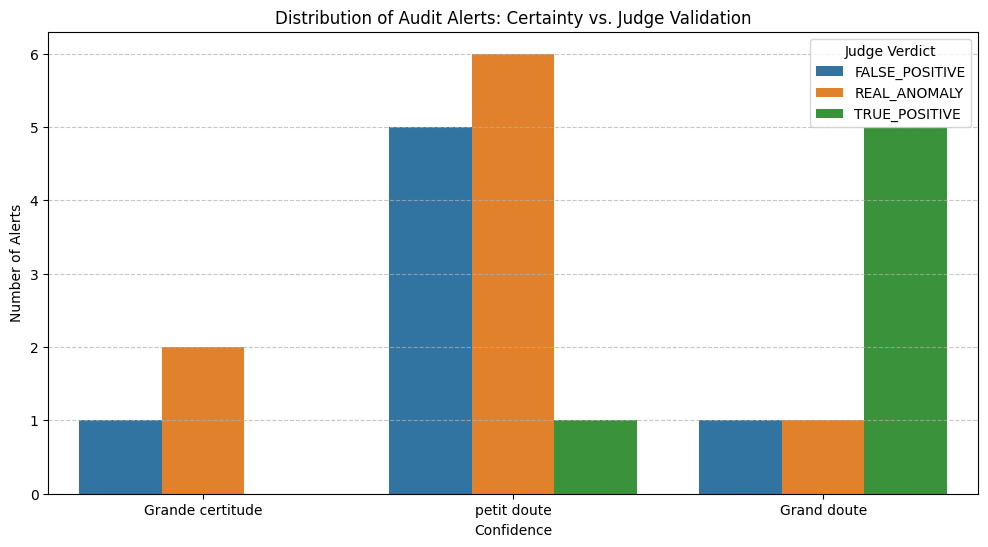

Detailed NLI Status breakdown by Confidence Level:


NLI Status,CONTRADICTION,NEUTRE,SKIPPED_NUM_FAIL
Confidence,,,
Grand doute,1,1,5
Grande certitude,3,0,0
petit doute,0,12,0


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data from the anomalies list
data = []
for a in anomalies:
    data.append({
        'Confidence': a.get('confidence_level', 'Unknown'),
        'Judge Verdict': a.get('llm_judge', {}).get('category', 'UNJUDGED'),
        'NLI Status': a.get('nli_status', 'N/A'),
        'Anomaly Type': a.get('anomaly_type', 'N/A')
    })

df_stats = pd.DataFrame(data)

# Visualization: Confidence vs Judge Category
plt.figure(figsize=(12, 6))
sns.countplot(data=df_stats, x='Confidence', hue='Judge Verdict', order=['Grande certitude', 'petit doute', 'Grand doute'])
plt.title('Distribution of Audit Alerts: Certainty vs. Judge Validation')
plt.ylabel('Number of Alerts')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Summary table for NLI sensitivity analysis
nli_analysis = df_stats.groupby(['Confidence', 'NLI Status']).size().unstack(fill_value=0)
print("Detailed NLI Status breakdown by Confidence Level:")
display(nli_analysis)

# Nouvelle section

In [ ]:
import os
import multiprocessing

# Get the number of CPU cores available
cores = multiprocessing.cpu_count()
print(f'Number of CPU cores: {cores}')

# Practical advice for your ThreadPoolExecutor:
# For API-heavy tasks (I/O bound), workers = cores * 5 is a common rule of thumb.
# For heavy local processing (CPU bound), workers = cores is usually the limit.

Number of CPU cores: 2
